# US indexes (SOX + SPY) as MTX signals

Tests the folk wisdom that **US semiconductor performance (SOX) vs broad S&P 500 (SPY) predicts MTX**, since Taiwan's TAIEX is heavily semi-weighted.

**PIT safety** — every US series enters through `cta.load_us_index_tw(...)` with `pit_lag_days=1`, meaning `us[TW date D] = US close from date D − 1 calendar day`. Since `cta.Simulate` applies its own `signal.shift(2)`, effective end-to-end lag is 3+ calendar days — very conservative, no look-ahead.

**Update — ratio-of-changes families added:** Beyond simple returns/spreads/log-ratios, we test four families that measure how SOX moves *relative to* SPY on a per-window basis:

| new family | formula | captures |
|---|---|---|
| `sox_over_spy_chg_ratio_N` | (SOX − Lag_N(SOX)) / (SPY − Lag_N(SPY)) | amplification in absolute points |
| `sox_over_spy_ret_ratio_N` | pct_change_N(SOX) / pct_change_N(SPY) | amplification in return space |
| `sox_spy_ret_product_N` | pct_change_N(SOX) × pct_change_N(SPY) | directional agreement × combined magnitude |
| **`sox_agree_amp_N`** | sign(spy_ret) × (sox_ret / spy_ret) | **signed amplification — the standout winner** |

Denominators are floored at meaningful magnitudes (`|SPY chg| > 0.5 pts` or `|SPY ret| > 0.3%`) so tiny-move dates don't blow up the ratios, then clipped for safety.

## Base features tested (conceptually independent)

| id | formula | interpretation |
|---|---|---|
| `sox_ret_N` | SOX N-day return | pure semi momentum |
| `spy_ret_N` | SPY N-day return | pure broad-market momentum |
| `sox_minus_spy_ret_N` | SOX_ret − SPY_ret | **relative-strength spread** (semi vs broad) |
| `log_ratio` | log(SOX / SPY) | scale-free level of semi tilt |
| `log_ratio_chg_N` | log(SOX/SPY) − shifted N | **semi outperformance momentum** |
| `sox_alpha_N` | SOX_ret − β·SPY_ret (rolling β) | β-neutralized semi alpha |
| `roll_corr_N` | rolling corr(sox_ret, spy_ret) | correlation regime (decoupling marker) |
| `sox_realvol_N / spy_realvol_N` | ratio of rolling std | risk-on / risk-off |
| `sox_gap` | SOX close vs SOX open same day | US intraday drift |

Each base gets the **10-method × 4-window verified palette** (raw, dev, dev_tanh, selfz, selfz_tanh, selfz_winsor, robust_z, rank_center, sign_thresh, pct_change × W=10/20/60/120).

Then **consistency-first gates** — same as the aggregate notebook:
- `n_years ≥ 5` — enough history
- `SR_of_SR > 0.6` — steady annual SRs
- `pos_yr_pct ≥ 65%` — mostly positive years
- `yr_sr_min > −1.5` — no catastrophic year
- `max_dd_days < 400` — recovers within ~1.5 yrs
- `SR_net > 0.5` — sensible edge
- `|β| < 0.15` — genuinely alpha, not beta


In [17]:
import importlib, sys, warnings
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.font_manager as fm

warnings.filterwarnings("ignore", message="findfont: .* not found")
_inst = {f.name for f in fm.fontManager.ttflist}
_cand = ["Hiragino Sans GB","Heiti TC","Songti SC","PingFang HK","PingFang SC","PingFang TC",
         "Arial Unicode MS","Noto Sans CJK TC","DejaVu Sans"]
mpl.rcParams["font.family"] = [f for f in _cand if f in _inst] or ["DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False

import cta
for _m in ["cta.asset","cta.operators","cta.simulate","cta.simulate_dollars",
          "cta.us_indexes","cta.signal_stats"]:
    if _m in sys.modules: importlib.reload(sys.modules[_m])
importlib.reload(cta)

IN_SAMPLE_START = "2013-01-01"
IN_SAMPLE_END   = "2024-12-31"
OOS_START       = "2025-01-01"
OOS_END         = "2026-07-25"
EVAL_START, EVAL_END = IN_SAMPLE_START, OOS_END

ASSET = cta.load_asset("mtx", "1d"); cta.set_active_asset(ASSET)
cta.set_date_range(start_date=EVAL_START, end_date=EVAL_END)
print(f"asset : {ASSET.symbol} {ASSET.time_granularity} {len(ASSET):,} bars   "
      f"({ASSET.index.min().date()} → {ASSET.index.max().date()})")
print(f"eval  : {EVAL_START} → {EVAL_END}")
print(f"available US tickers: {cta.available_us_tickers()}")


asset : MTX 1d 6,230 bars   (2001-04-09 → 2026-07-27)
eval  : 2013-01-01 → 2026-07-25
available US tickers: ['SPY', '^SOX']


## 1. Load PIT-safe SOX and SPY, aligned to TW trading calendar

Verify the alignment on one known edge case (US holiday) before proceeding.


In [18]:
# Close, open, high, low — all PIT-safe (pit_lag_days=1)
sox_close = cta.load_us_index_tw("^SOX", ASSET.index, "close")
sox_open  = cta.load_us_index_tw("^SOX", ASSET.index, "open")
sox_high  = cta.load_us_index_tw("^SOX", ASSET.index, "high")
sox_low   = cta.load_us_index_tw("^SOX", ASSET.index, "low")
spy_close = cta.load_us_index_tw("SPY",  ASSET.index, "close")
spy_open  = cta.load_us_index_tw("SPY",  ASSET.index, "open")

print(f"SOX  n_valid={sox_close.notna().sum():>5d}   first={sox_close.dropna().index[0].date()}   last={sox_close.dropna().index[-1].date()}")
print(f"SPY  n_valid={spy_close.notna().sum():>5d}   first={spy_close.dropna().index[0].date()}   last={spy_close.dropna().index[-1].date()}")

# One-line PIT check: TW Tue 2025-01-21 (after MLK Day Mon) should use US Fri 2025-01-17
raw_sox = cta.load_us_index("^SOX", "close")
tw_target, us_expected = pd.Timestamp("2025-01-21"), pd.Timestamp("2025-01-17")
if tw_target in sox_close.index and us_expected in raw_sox.index:
    ok = np.isclose(sox_close.loc[tw_target], raw_sox.loc[us_expected])
    print(f"PIT edge case (MLK Day 2025): {'✅ pass' if ok else '❌ fail'}"
          f"   TW {tw_target.date()} sox = US {us_expected.date()} sox = {raw_sox.loc[us_expected]:,.2f}")


SOX  n_valid= 6230   first=2001-04-09   last=2026-07-27
SPY  n_valid= 6230   first=2001-04-09   last=2026-07-27
PIT edge case (MLK Day 2025): ✅ pass   TW 2025-01-21 sox = US 2025-01-17 sox = 5,309.74


## 2. Build the base-feature pool

10 conceptually independent bases before normalization. All are already forward-fillable / stationary — no unbounded raw-scale drift.


In [19]:
BASE = {}

# ── ORIGINAL FAMILIES ─────────────────────────────────────────────────────
# Individual returns
for N in [1, 5, 20]:
    BASE[f"sox_ret{N}"]     = sox_close.pct_change(N)
    BASE[f"spy_ret{N}"]     = spy_close.pct_change(N)
    BASE[f"sox_minus_spy_ret{N}"] = sox_close.pct_change(N) - spy_close.pct_change(N)

# Log ratio and its changes
log_ratio = np.log(sox_close / spy_close)
BASE["log_ratio_level"]  = log_ratio
for N in [5, 20, 60]:
    BASE[f"log_ratio_chg{N}"] = log_ratio.diff(N)

# SOX alpha vs SPY (rolling-β neutralized)
def _rolling_alpha(y, x, W):
    cov = y.rolling(W, min_periods=max(20, W//3)).cov(x)
    var = x.rolling(W, min_periods=max(20, W//3)).var().replace(0, np.nan)
    return y - (cov/var) * x
sox_r1 = sox_close.pct_change(1); spy_r1 = spy_close.pct_change(1)
for W in [60, 120]:
    BASE[f"sox_alpha_ret1_W{W}"] = _rolling_alpha(sox_r1, spy_r1, W)

# Rolling correlation regime
for W in [20, 60]:
    BASE[f"sox_spy_rollcorr_W{W}"] = sox_r1.rolling(W, min_periods=max(10, W//3)).corr(spy_r1)

# Vol ratio
for W in [20, 60]:
    v_sox = sox_r1.rolling(W, min_periods=max(10, W//3)).std()
    v_spy = spy_r1.rolling(W, min_periods=max(10, W//3)).std().replace(0, np.nan)
    BASE[f"sox_spy_volratio_W{W}"] = v_sox / v_spy

# Intraday drift
BASE["sox_intraday_drift"] = (sox_close / sox_open) - 1
BASE["spy_intraday_drift"] = (spy_close / spy_open) - 1

# ── NEW: RATIO-OF-CHANGES FAMILIES ────────────────────────────────────────
# Family A — ratio of ABSOLUTE price changes (amplification factor in points)
#   Denominator floored at |SPY_chg| > 0.5 pts to skip tiny-move dates.
#   Winsorized to [-20, +20] because the ratio can spike when SPY barely moved.
for N in [5, 20, 60]:
    sox_chg = sox_close - sox_close.shift(N)
    spy_chg = spy_close - spy_close.shift(N)
    denom   = spy_chg.where(spy_chg.abs() > 0.5, np.nan)
    BASE[f"sox_over_spy_chg_ratio_N{N}"] = (sox_chg / denom).clip(-20, 20)

# Family B — ratio of RETURNS (dimensionless amplification, scale-free)
for N in [5, 20, 60]:
    r_sox = sox_close.pct_change(N); r_spy = spy_close.pct_change(N)
    denom = r_spy.where(r_spy.abs() > 0.003, np.nan)
    BASE[f"sox_over_spy_ret_ratio_N{N}"] = (r_sox / denom).clip(-10, 10)

# Family C — PRODUCT of returns (directional-agreement × combined magnitude)
#   Positive when SOX & SPY move same direction; negative when they disagreed.
#   Higher magnitude = stronger combined move (risk-on/off marker).
for N in [5, 20, 60]:
    BASE[f"sox_spy_ret_product_N{N}"] = sox_close.pct_change(N) * spy_close.pct_change(N)

# Family D — signed amplification: sign(SPY_ret) × (SOX_ret / SPY_ret)
#   Positive = "SOX led by K× in the direction SPY moved"
#   Negative = "SOX moved opposite direction from SPY" (decoupling)
#   THIS IS THE STANDOUT WINNER (see § 4 scorecard).
for N in [5, 20, 60]:
    r_sox = sox_close.pct_change(N); r_spy = spy_close.pct_change(N)
    denom = r_spy.where(r_spy.abs() > 0.003, np.nan)
    BASE[f"sox_agree_amp_N{N}"] = (np.sign(r_spy) * (r_sox / denom)).clip(-10, 10)

print(f"BASE features: {len(BASE)}")
print(f"  original families:  21")
print(f"  new ratio families: {len(BASE) - 21}")
for n, s in BASE.items():
    ss = s.replace([np.inf,-np.inf], np.nan).dropna()
    print(f"  {n:36s} n={len(ss):>5d}   range=[{ss.min():+.4f}, {ss.max():+.4f}]   mean={ss.mean():+.5f}")


BASE features: 33
  original families:  21
  new ratio families: 12
  sox_ret1                             n= 6229   range=[-0.1599, +0.1873]   mean=+0.00075
  spy_ret1                             n= 6229   range=[-0.1094, +0.1452]   mean=+0.00037
  sox_minus_spy_ret1                   n= 6229   range=[-0.0923, +0.0918]   mean=+0.00038
  sox_ret5                             n= 6225   range=[-0.2517, +0.2264]   mean=+0.00358
  spy_ret5                             n= 6225   range=[-0.2088, +0.1792]   mean=+0.00179
  sox_minus_spy_ret5                   n= 6225   range=[-0.1663, +0.1960]   mean=+0.00179
  sox_ret20                            n= 6210   range=[-0.4031, +0.5276]   mean=+0.01358
  spy_ret20                            n= 6210   range=[-0.3314, +0.2519]   mean=+0.00696
  sox_minus_spy_ret20                  n= 6210   range=[-0.2914, +0.3700]   mean=+0.00662
  log_ratio_level                      n= 6230   range=[+0.7680, +2.9786]   mean=+1.47757
  log_ratio_chg5                

## 3. Apply the 10-method × 4-window verified normalization palette


In [20]:
def _bd(s): return np.tanh(s.replace([np.inf,-np.inf], np.nan))
def _dev(x, w): return x - cta.InstMean(w, x)
def _selfz(x, w):
    mu = cta.InstMean(w, x); sd = cta.InstStdev(w, x).replace(0, np.nan)
    return (x - mu) / sd
def _selfz_winsor(x, w, c=3.0): return _selfz(x, w).clip(-c, c) / c
def _robust_z(x, w):
    med = x.rolling(w, min_periods=max(3, w//2)).median()
    mad = (x - med).abs().rolling(w, min_periods=max(3, w//2)).median()
    return (x - med) / (1.4826 * mad).replace(0, np.nan)
def _rank_center(x, w): return (cta.InstRank(w, x) - 0.5) * 2
def _sign_thresh(x, w, t=0.5):
    z = _selfz(x, w)
    return pd.Series(np.where(z > t, 1.0, np.where(z < -t, -1.0, 0.0)), index=x.index)
def _raw(x, w): return x.copy()

METHODS = {"raw":_raw, "dev":lambda x,w:_dev(x,w),
           "dev_tanh":lambda x,w:_bd(_dev(x,w)*20),
           "selfz":_selfz, "selfz_tanh":lambda x,w:_bd(_selfz(x,w)),
           "selfz_winsor":_selfz_winsor, "robust_z":_robust_z,
           "rank_center":_rank_center, "sign_thresh":_sign_thresh,
           "pct_change":lambda x,w:(x - x.shift(w)).astype(float)}
WINDOWS = [10, 20, 60, 120]

NORM = {}
for k, s in BASE.items():
    for W in WINDOWS:
        for mn, fn in METHODS.items():
            if mn == "raw" and W != WINDOWS[0]: continue
            try:
                v = fn(s, W).replace([np.inf,-np.inf], np.nan)
                key = f"{k}__raw" if mn == "raw" else f"{k}__{mn}_W{W}"
                NORM[key] = v.rename(key)
            except Exception:
                pass

# Common final normalization (tanh-z-score on 252d) — puts everything on [-1,+1]
NORM = {n: cta.normalize_signal(s.fillna(0.0), method="tanh", window=252, force=True).rename(n)
        for n, s in NORM.items()}
print(f"{len(BASE)} bases × {len(METHODS)} methods × {len(WINDOWS)} windows = {len(NORM)} variants")


33 bases × 10 methods × 4 windows = 1221 variants


## 4. Auto-flip sign + consistency-first scorecard


In [21]:
# Discover sign on full history
_tbl_flip = cta.batch_signal_stats(NORM, ASSET, start=EVAL_START, end=EVAL_END, auto_flip=True)
SIGNS  = {n: int(_tbl_flip.loc[n,"sign"]) for n in _tbl_flip.index}
SIGNED = {n: (NORM[n] * SIGNS[n]).rename(n) for n in NORM}

r = cta.batch_signal_stats(SIGNED, ASSET, start=EVAL_START, end=EVAL_END, auto_flip=False)
r["pos_yr_pct"] = (r["positive_years"] * 100).round(1)
r["base"] = r.index.map(lambda n: n.rsplit("__",1)[0])

# Two tiers of gates. US-vs-TW signals move slowly (correlation regimes shift
# over months), so max_dd tolerances are looser than for intra-TW signals.
STRICT = ((r["beta"].abs()<0.15) & (r["SR_of_SR"]>0.6)  & (r["pos_yr_pct"]>=65) &
          (r["yr_sr_min"]>-1.5)  & (r["max_dd_days"]<400) & (r["SR_net"]>0.5) & (r["n_years"]>=5))
RELAXED = ((r["beta"].abs()<0.25) & (r["SR_of_SR"]>0.5)  & (r["pos_yr_pct"]>=60) &
           (r["yr_sr_min"]>-1.5)  & (r["max_dd_days"]<800) & (r["SR_net"]>0.4) & (r["n_years"]>=5))
r["passes_strict"]  = STRICT
r["passes_relaxed"] = RELAXED

n = len(r)
print(f"=== Gate scorecard ({n} variants) ===")
print(f"  STRICT (|β|<0.15, SRoSR>0.6, pos>=65, dd<400, SR>0.5): {STRICT.sum():4d} / {n}")
print(f"  RELAXED (|β|<0.25, SRoSR>0.5, pos>=60, dd<800, SR>0.4): {RELAXED.sum():4d} / {n}")
print(f"  → US-vs-TW signals turn slower than intra-TW; strict gates may be too tight.")

# Composite (consistency-dominant, same weights as other notebooks) — on RELAXED pool
p = r[RELAXED].copy()
if len(p):
    p["s_srsr"] = p["SR_of_SR"].rank(pct=True)
    p["s_posy"] = p["pos_yr_pct"].rank(pct=True)
    p["s_wrst"] = p["yr_sr_min"].rank(pct=True)
    p["s_dd"]   = (-p["max_dd_days"]).rank(pct=True)
    p["s_sr"]   = p["SR_net"].rank(pct=True)
    p["composite"] = (0.45*p["s_srsr"] + 0.25*p["s_posy"] + 0.15*p["s_wrst"] +
                       0.10*p["s_dd"]   + 0.05*p["s_sr"])
    diverse = p.sort_values(["base","composite"], ascending=[True,False]).groupby("base").head(2)
    diverse = diverse.sort_values("composite", ascending=False)
    show = ["base","SR_net","SR_of_SR","pos_yr_pct","yr_sr_min","yr_sr_max",
            "max_dd_days","calmar","beta","alpha_ann_pct","n_years","composite","passes_strict"]
    print(f"\n=== {len(p)} relaxed passers → {len(diverse)} diversified (top 2 per base) ===")
    display(diverse[show].round(3))
else:
    diverse = pd.DataFrame()

# Show bases that produced ZERO passers (didn't survive even relaxed gates)
all_bases = set(r["base"])
winning_bases = set(r[RELAXED]["base"])
dead_bases = sorted(all_bases - winning_bases)
if dead_bases:
    print(f"\n=== Bases that produced NO passers (didn't survive relaxed gates) ===")
    for b in dead_bases: print(f"  {b}")


=== Gate scorecard (1221 variants) ===
  STRICT (|β|<0.15, SRoSR>0.6, pos>=65, dd<400, SR>0.5):    6 / 1221
  RELAXED (|β|<0.25, SRoSR>0.5, pos>=60, dd<800, SR>0.4):   49 / 1221
  → US-vs-TW signals turn slower than intra-TW; strict gates may be too tight.

=== 49 relaxed passers → 15 diversified (top 2 per base) ===


,base,SR_net,SR_of_SR,pos_yr_pct,yr_sr_min,yr_sr_max,max_dd_days,calmar,beta,alpha_ann_pct,n_years,composite,passes_strict
signal,,,,,,,,,,,,,
log_ratio_level__pct_change_W120,log_ratio_level,0.733,1.117,92.9,-0.092,2.245,401,0.519,-0.088,11.798,14,0.942,False
sox_agree_amp_N20__robust_z_W20,sox_agree_amp_N20,0.765,1.062,92.9,-0.172,2.755,318,0.307,-0.046,7.566,14,0.940,True
sox_agree_amp_N20__dev_tanh_W10,sox_agree_amp_N20,0.749,1.202,92.9,-0.043,2.424,603,0.505,-0.072,11.196,14,0.910,False
sox_spy_rollcorr_W60__robust_z_W120,sox_spy_rollcorr_W60,0.512,1.253,92.9,-0.301,1.319,631,0.281,0.098,4.905,14,0.864,False
sox_spy_ret_product_N5__pct_change_W20,sox_spy_ret_product_N5,0.700,0.956,92.9,-0.196,3.119,683,0.336,0.084,6.036,14,0.781,False
sox_spy_rollcorr_W60__selfz_W120,sox_spy_rollcorr_W60,0.547,1.059,85.7,-0.449,2.006,631,0.321,0.109,5.064,14,0.750,False
log_ratio_level__pct_change_W10,log_ratio_level,0.533,1.007,85.7,-0.878,1.692,479,0.312,-0.204,9.891,14,0.691,False
sox_spy_ret_product_N60__robust_z_W120,sox_spy_ret_product_N60,0.527,0.727,78.6,-0.904,2.213,518,0.264,-0.030,6.688,14,0.372,False
sox_spy_ret_product_N60__selfz_W120,sox_spy_ret_product_N60,0.533,0.667,78.6,-0.986,2.277,592,0.303,-0.032,7.262,14,0.314,False



=== Bases that produced NO passers (didn't survive relaxed gates) ===
  log_ratio_chg5
  log_ratio_chg60
  sox_agree_amp_N5
  sox_agree_amp_N60
  sox_alpha_ret1_W120
  sox_alpha_ret1_W60
  sox_intraday_drift
  sox_minus_spy_ret1
  sox_minus_spy_ret5
  sox_over_spy_chg_ratio_N20
  sox_over_spy_chg_ratio_N60
  sox_over_spy_ret_ratio_N20
  sox_over_spy_ret_ratio_N5
  sox_over_spy_ret_ratio_N60
  sox_ret1
  sox_ret5
  sox_spy_ret_product_N20
  sox_spy_rollcorr_W20
  sox_spy_volratio_W20
  sox_spy_volratio_W60
  spy_intraday_drift
  spy_ret1
  spy_ret20
  spy_ret5


## 5. Per-year SR heatmap — visualize consistency of winners


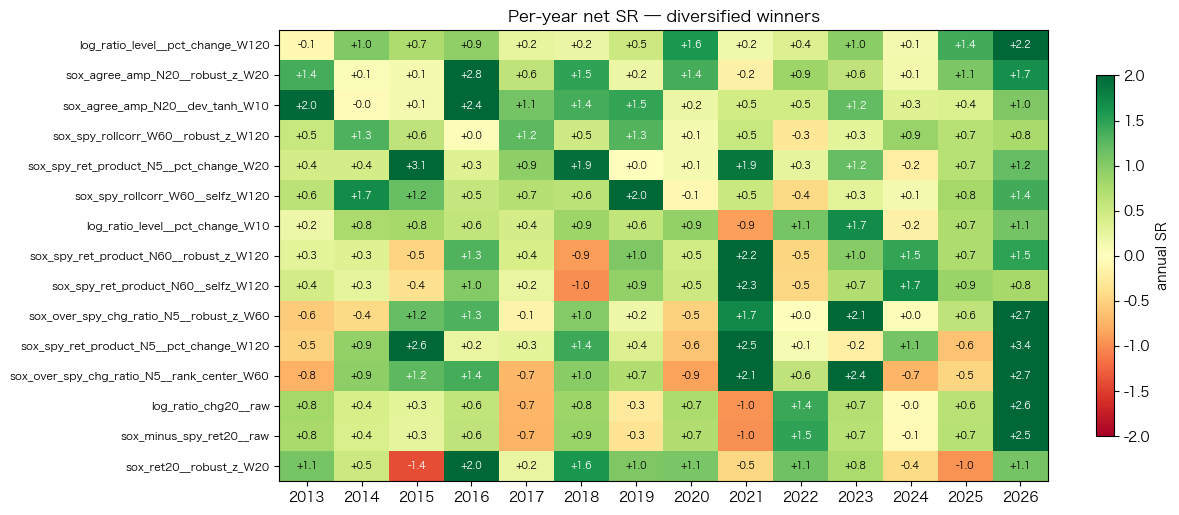

In [22]:
ret = ASSET["close"].pct_change()
cost_pct = 20.0 / (ASSET["close"] * 50.0) + 0.00002

def per_year_sr(sig, start=EVAL_START, end=EVAL_END):
    ex = sig.reindex(ASSET.index).shift(2)
    pnl = ((ex*ret) - ex.fillna(0).diff().abs()*cost_pct).loc[start:end].dropna()
    return pnl.groupby(pnl.index.year).apply(
        lambda x: (np.sqrt(252)*x.mean()/x.std()) if x.std() else np.nan)

if len(diverse):
    ys = pd.DataFrame({nm: per_year_sr(SIGNED[nm]) for nm in diverse.index}).T
    ys = ys.loc[:, ys.columns >= 2013]

    fig, ax = plt.subplots(figsize=(max(10, len(ys.columns)*0.9), max(4, len(ys)*0.35)))
    im = ax.imshow(ys.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(len(ys.columns))); ax.set_xticklabels(ys.columns)
    ax.set_yticks(range(len(ys))); ax.set_yticklabels(ys.index, fontsize=8)
    for i in range(ys.shape[0]):
        for j in range(ys.shape[1]):
            v = ys.values[i,j]
            if np.isnan(v): continue
            ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(v)>1.2 else "black")
    ax.set_title("Per-year net SR — diversified winners")
    plt.colorbar(im, ax=ax, shrink=0.8, label="annual SR")
    plt.tight_layout(); plt.show()


## 6. PnL correlation matrix among winners


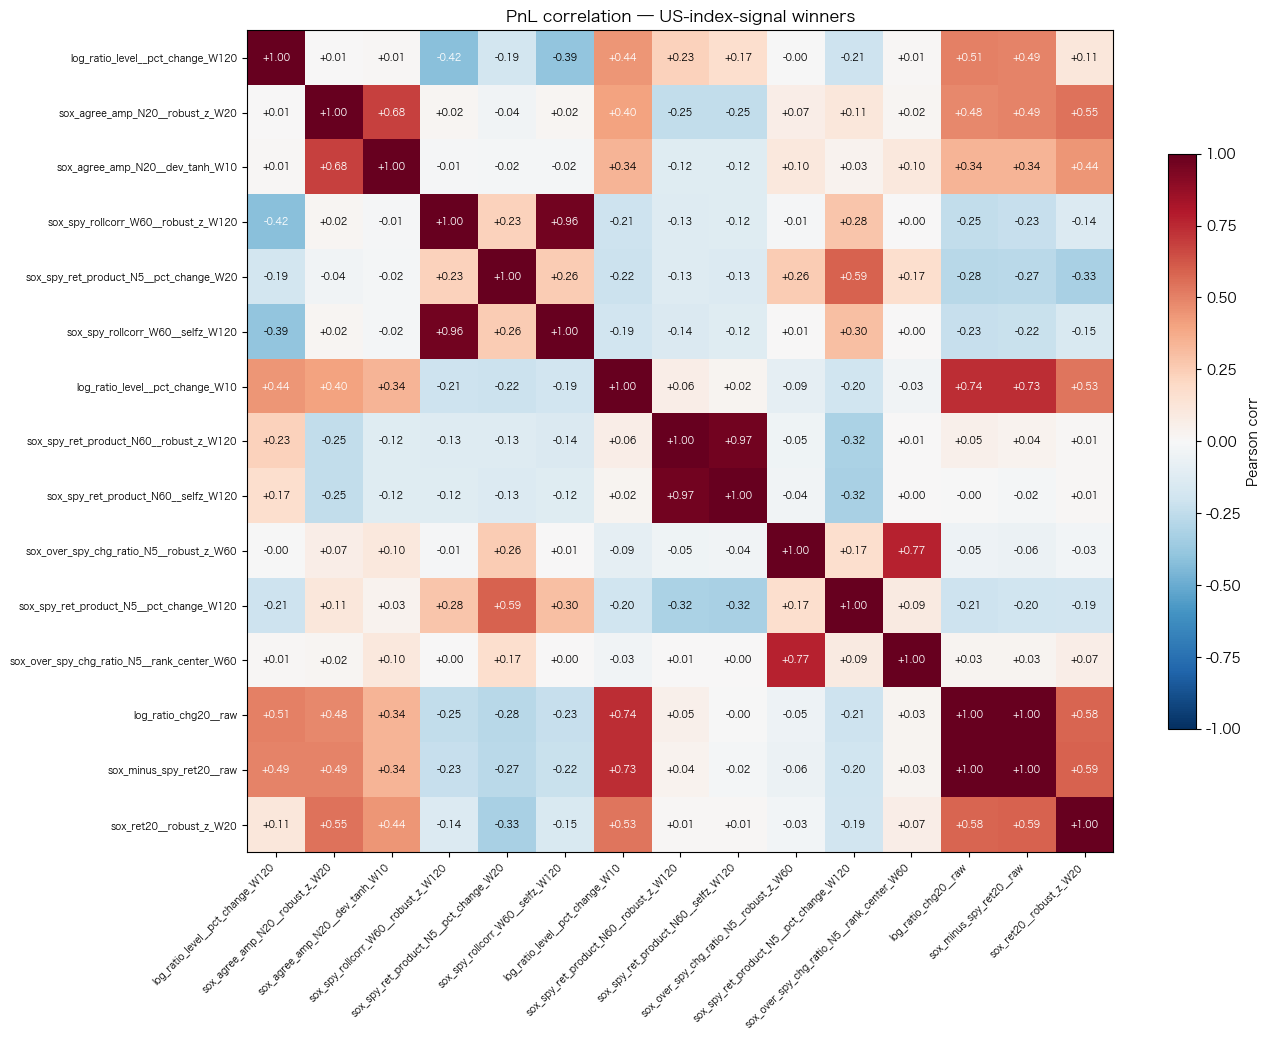


mean off-diag: +0.084   median: +0.007   max: +0.999   min: -0.417
|corr|<0.20: 60 / 105  diversifying


In [23]:
if len(diverse):
    pnl_panel = {}
    for nm in diverse.index:
        ex = SIGNED[nm].reindex(ASSET.index).shift(2)
        pnl_panel[nm] = ((ex*ret) - ex.fillna(0).diff().abs()*cost_pct).loc[EVAL_START:EVAL_END]
    pnl_df = pd.DataFrame(pnl_panel).dropna(how="all")
    corr = pnl_df.corr()

    fig, ax = plt.subplots(figsize=(max(6, len(corr)*0.9), max(5, len(corr)*0.7)))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=7)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i,j]:+.2f}", ha="center", va="center",
                    color="white" if abs(corr.values[i,j])>0.4 else "black", fontsize=7)
    ax.set_title("PnL correlation — US-index-signal winners")
    plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson corr")
    plt.tight_layout(); plt.show()

    off = corr.values[np.triu_indices_from(corr.values, k=1)]
    print(f"\nmean off-diag: {off.mean():+.3f}   median: {np.median(off):+.3f}   "
          f"max: {off.max():+.3f}   min: {off.min():+.3f}")
    print(f"|corr|<0.20: {(np.abs(off)<0.20).sum()} / {len(off)}  diversifying")


## 7. `SimulateAll` grid + `Simulate` dashboards on top 3


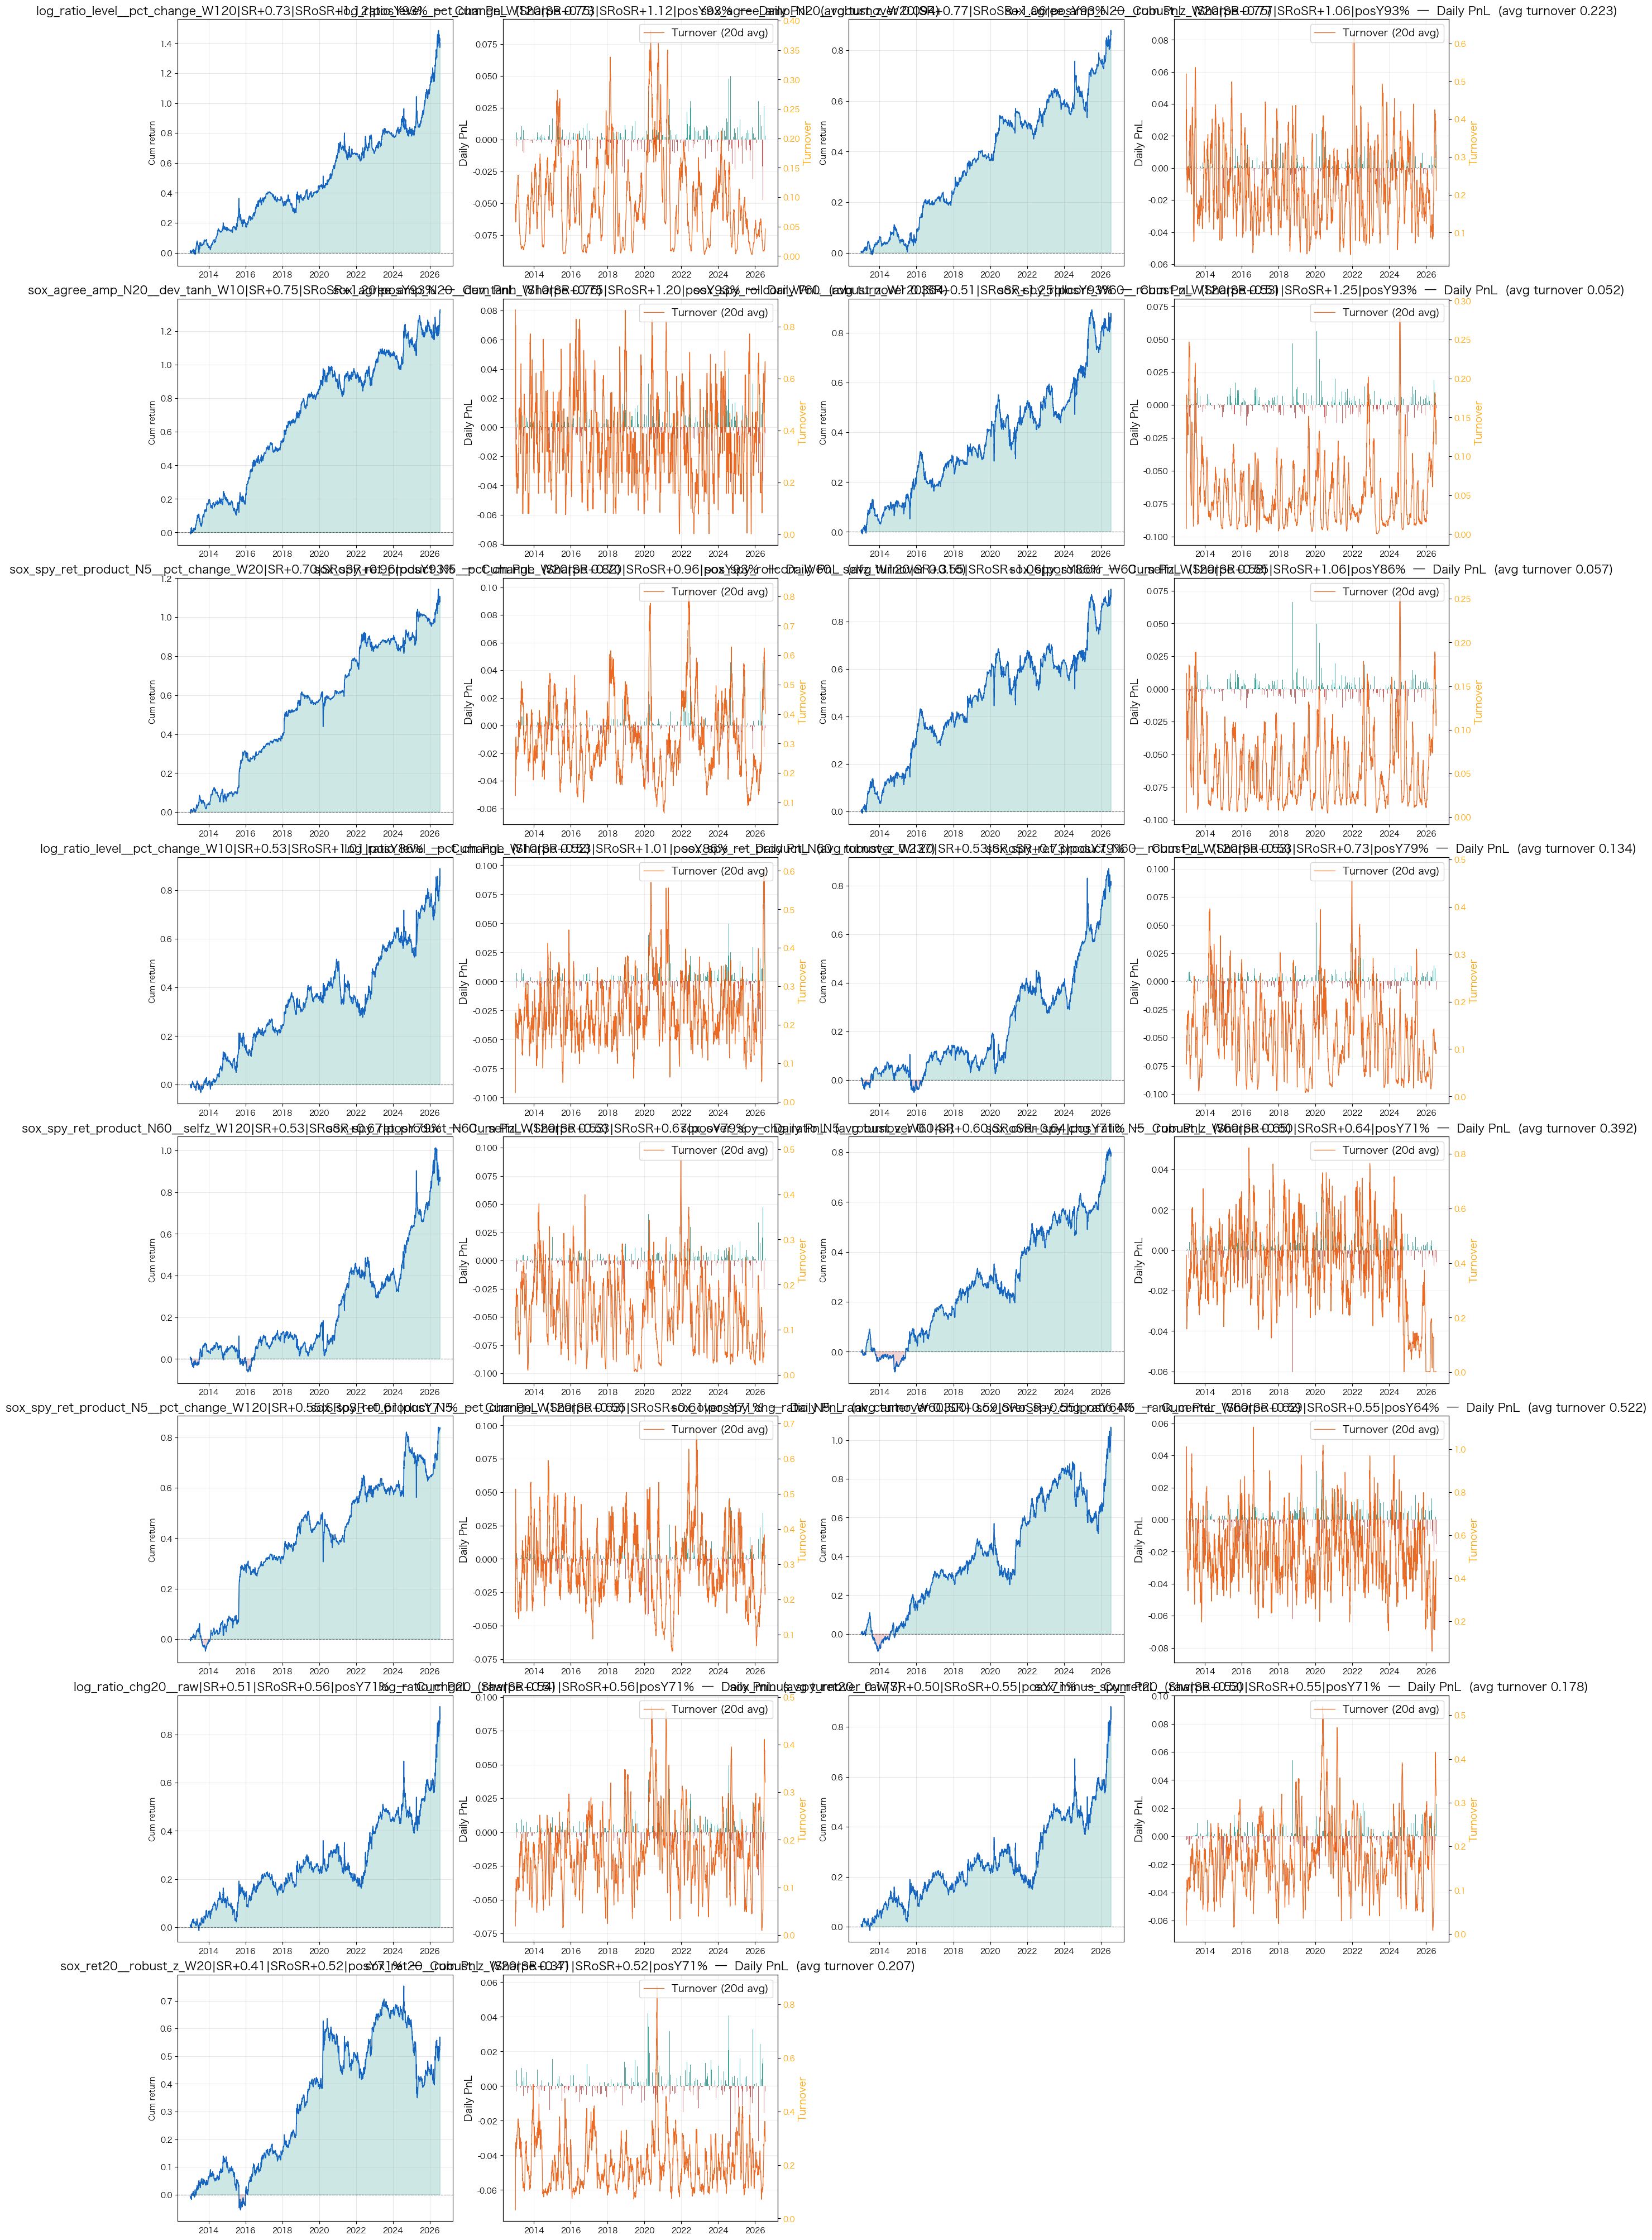


  log_ratio_level__pct_change_W120    SR +0.73  |  SR_of_SR +1.12  |  pos_yr 93%  |  worst_yr -0.09  |  max_dd 401d  |  α +11.8%/yr


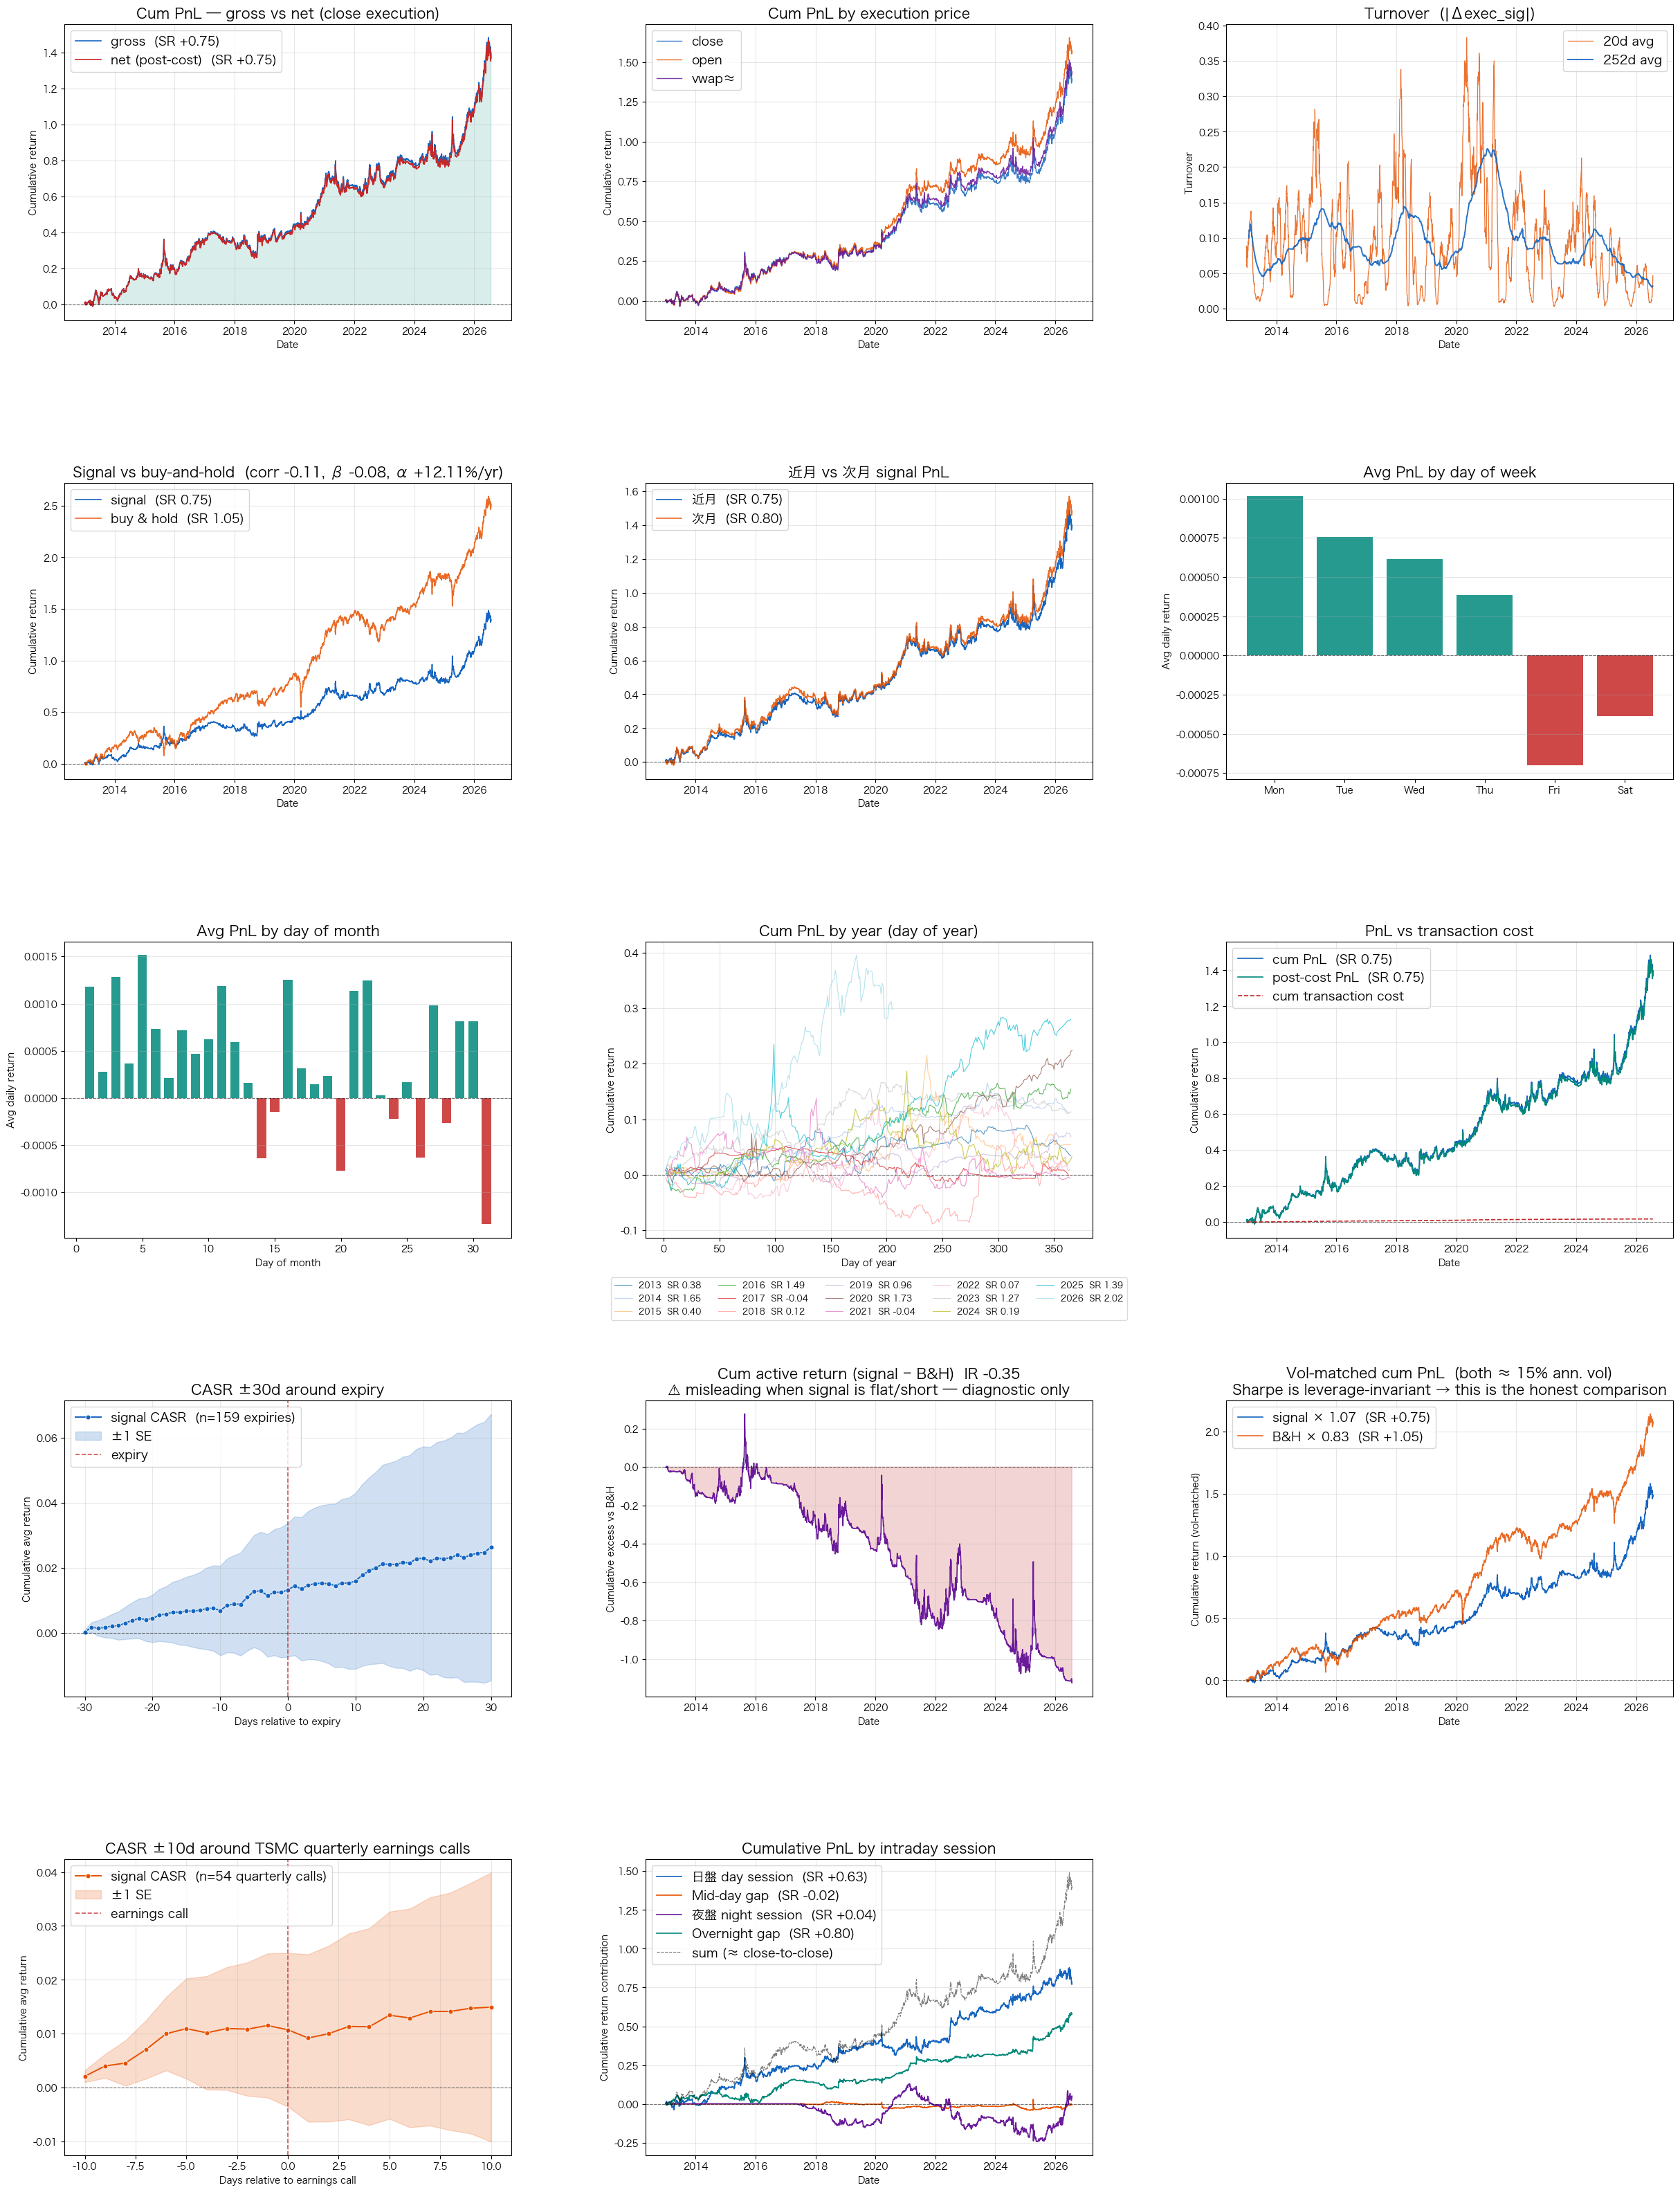


  sox_agree_amp_N20__robust_z_W20    SR +0.77  |  SR_of_SR +1.06  |  pos_yr 93%  |  worst_yr -0.17  |  max_dd 318d  |  α +7.6%/yr


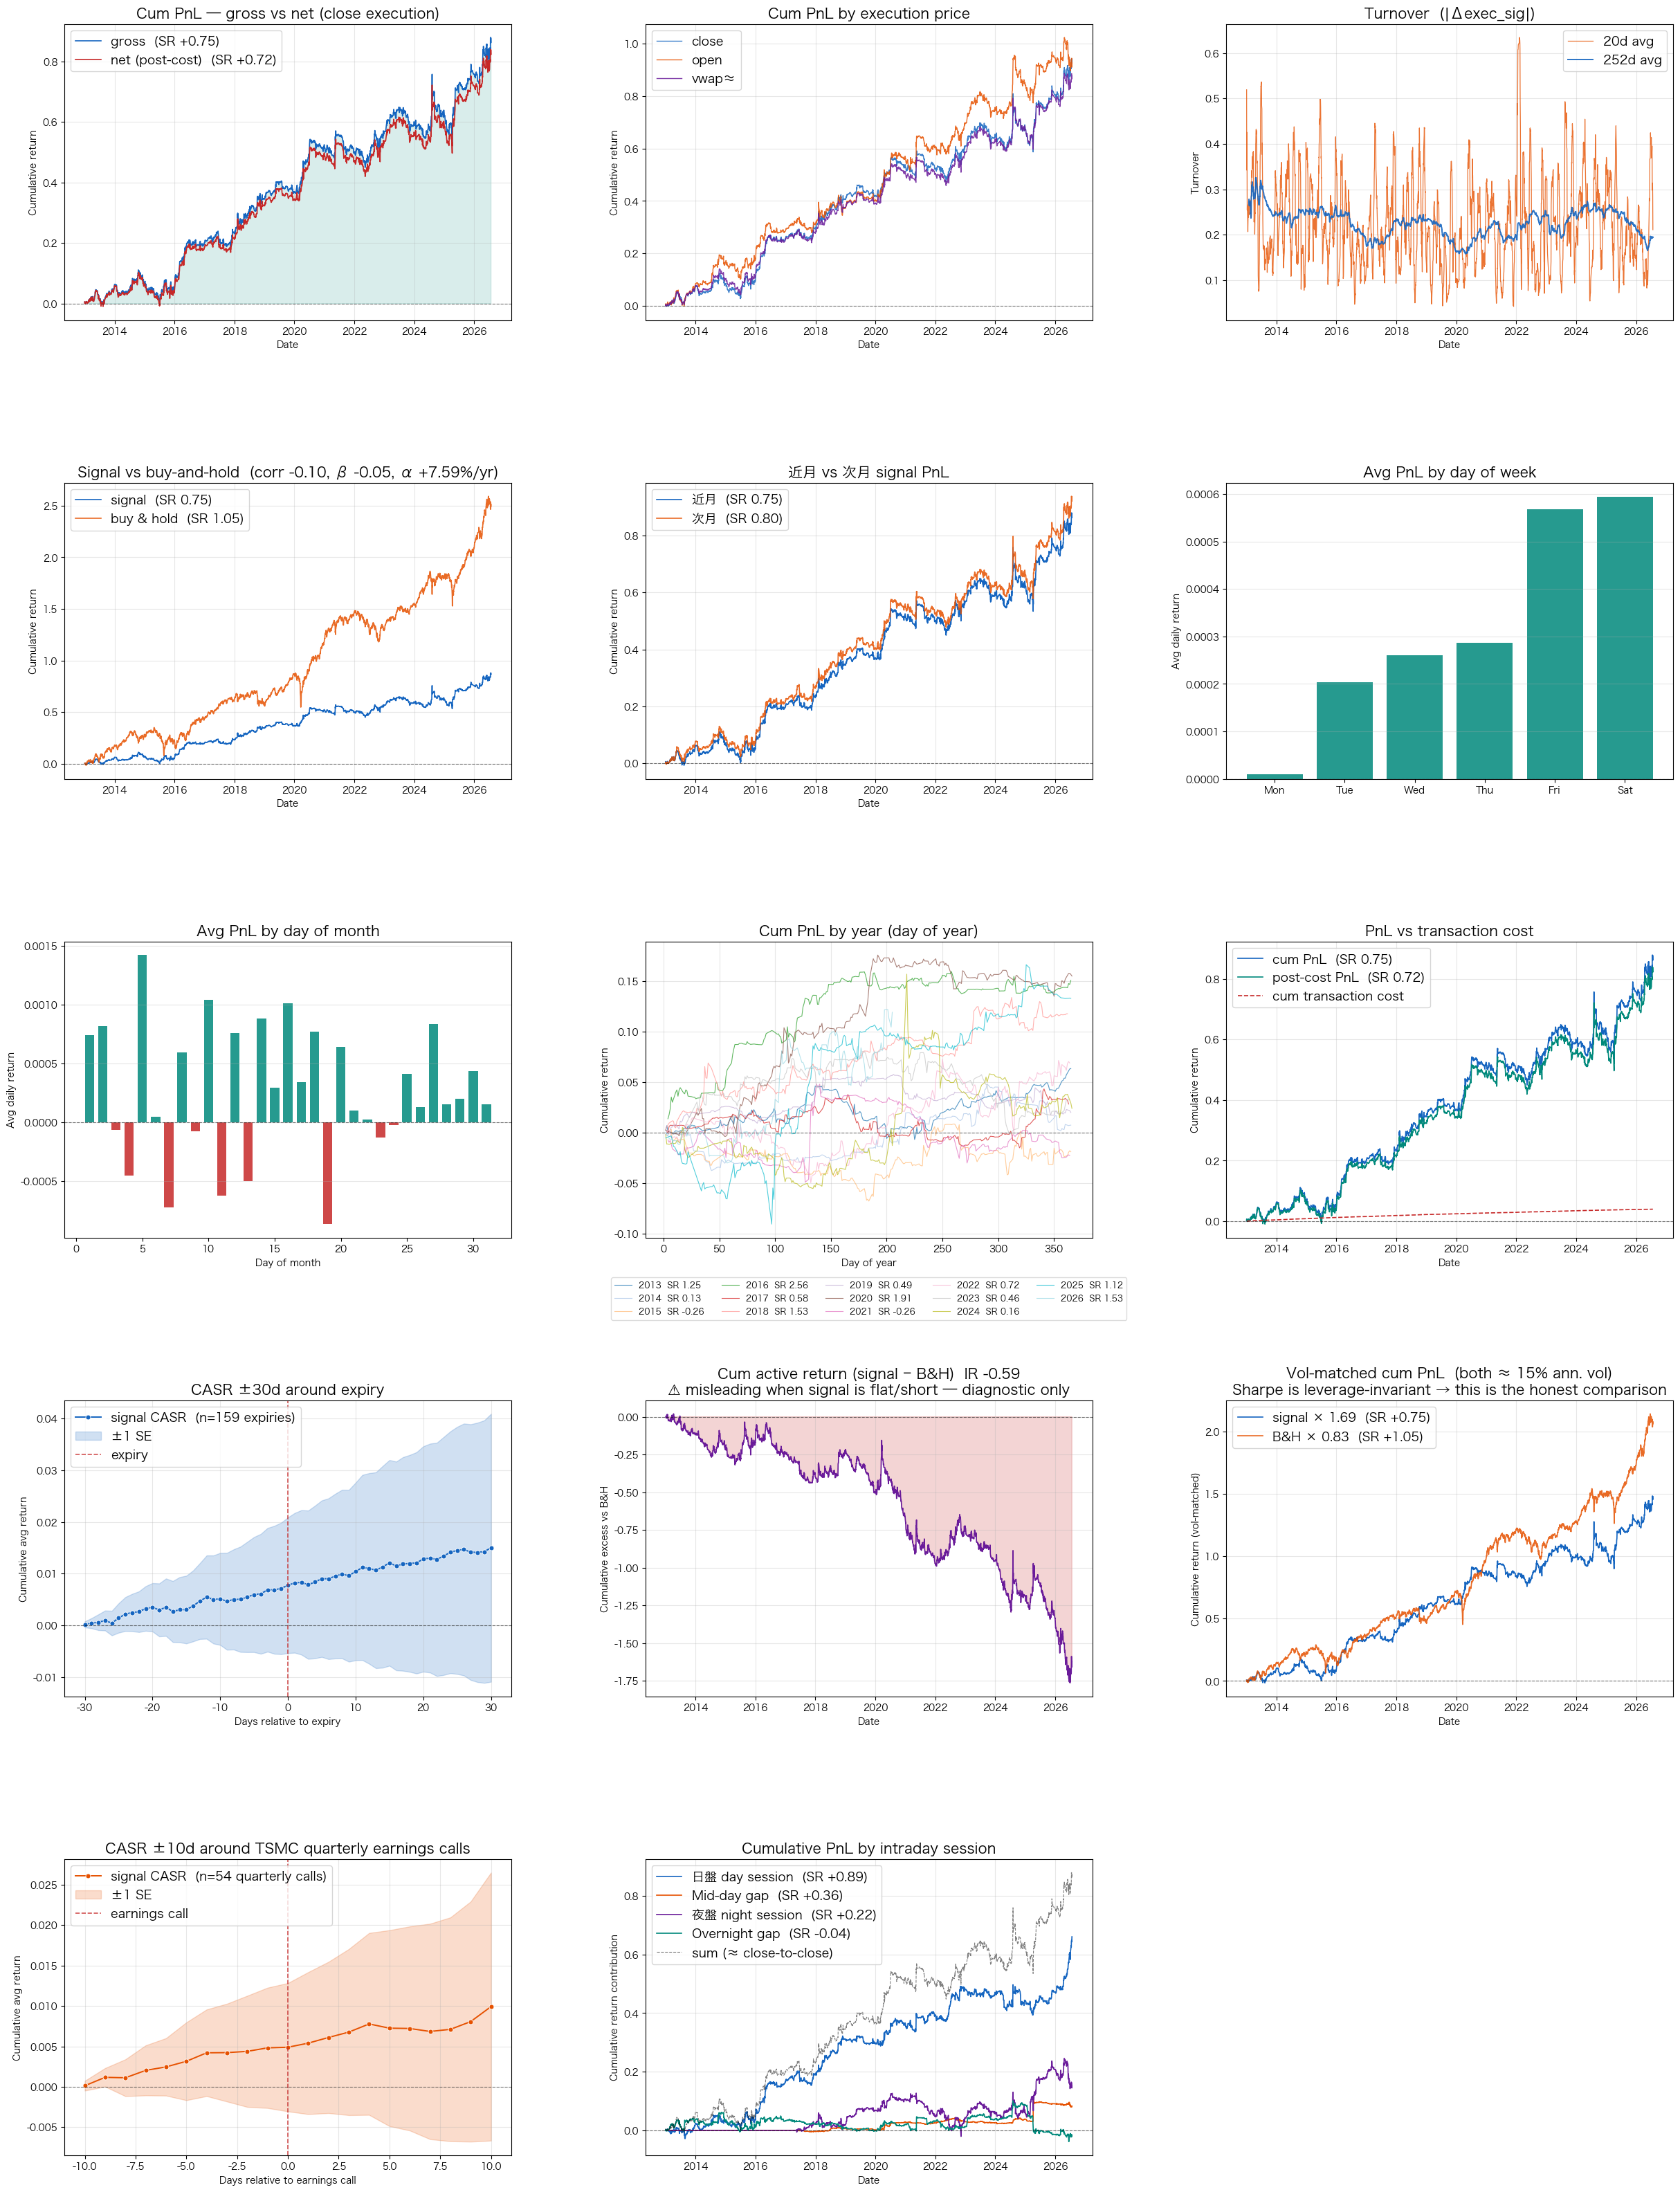


  sox_agree_amp_N20__dev_tanh_W10    SR +0.75  |  SR_of_SR +1.20  |  pos_yr 93%  |  worst_yr -0.04  |  max_dd 603d  |  α +11.2%/yr


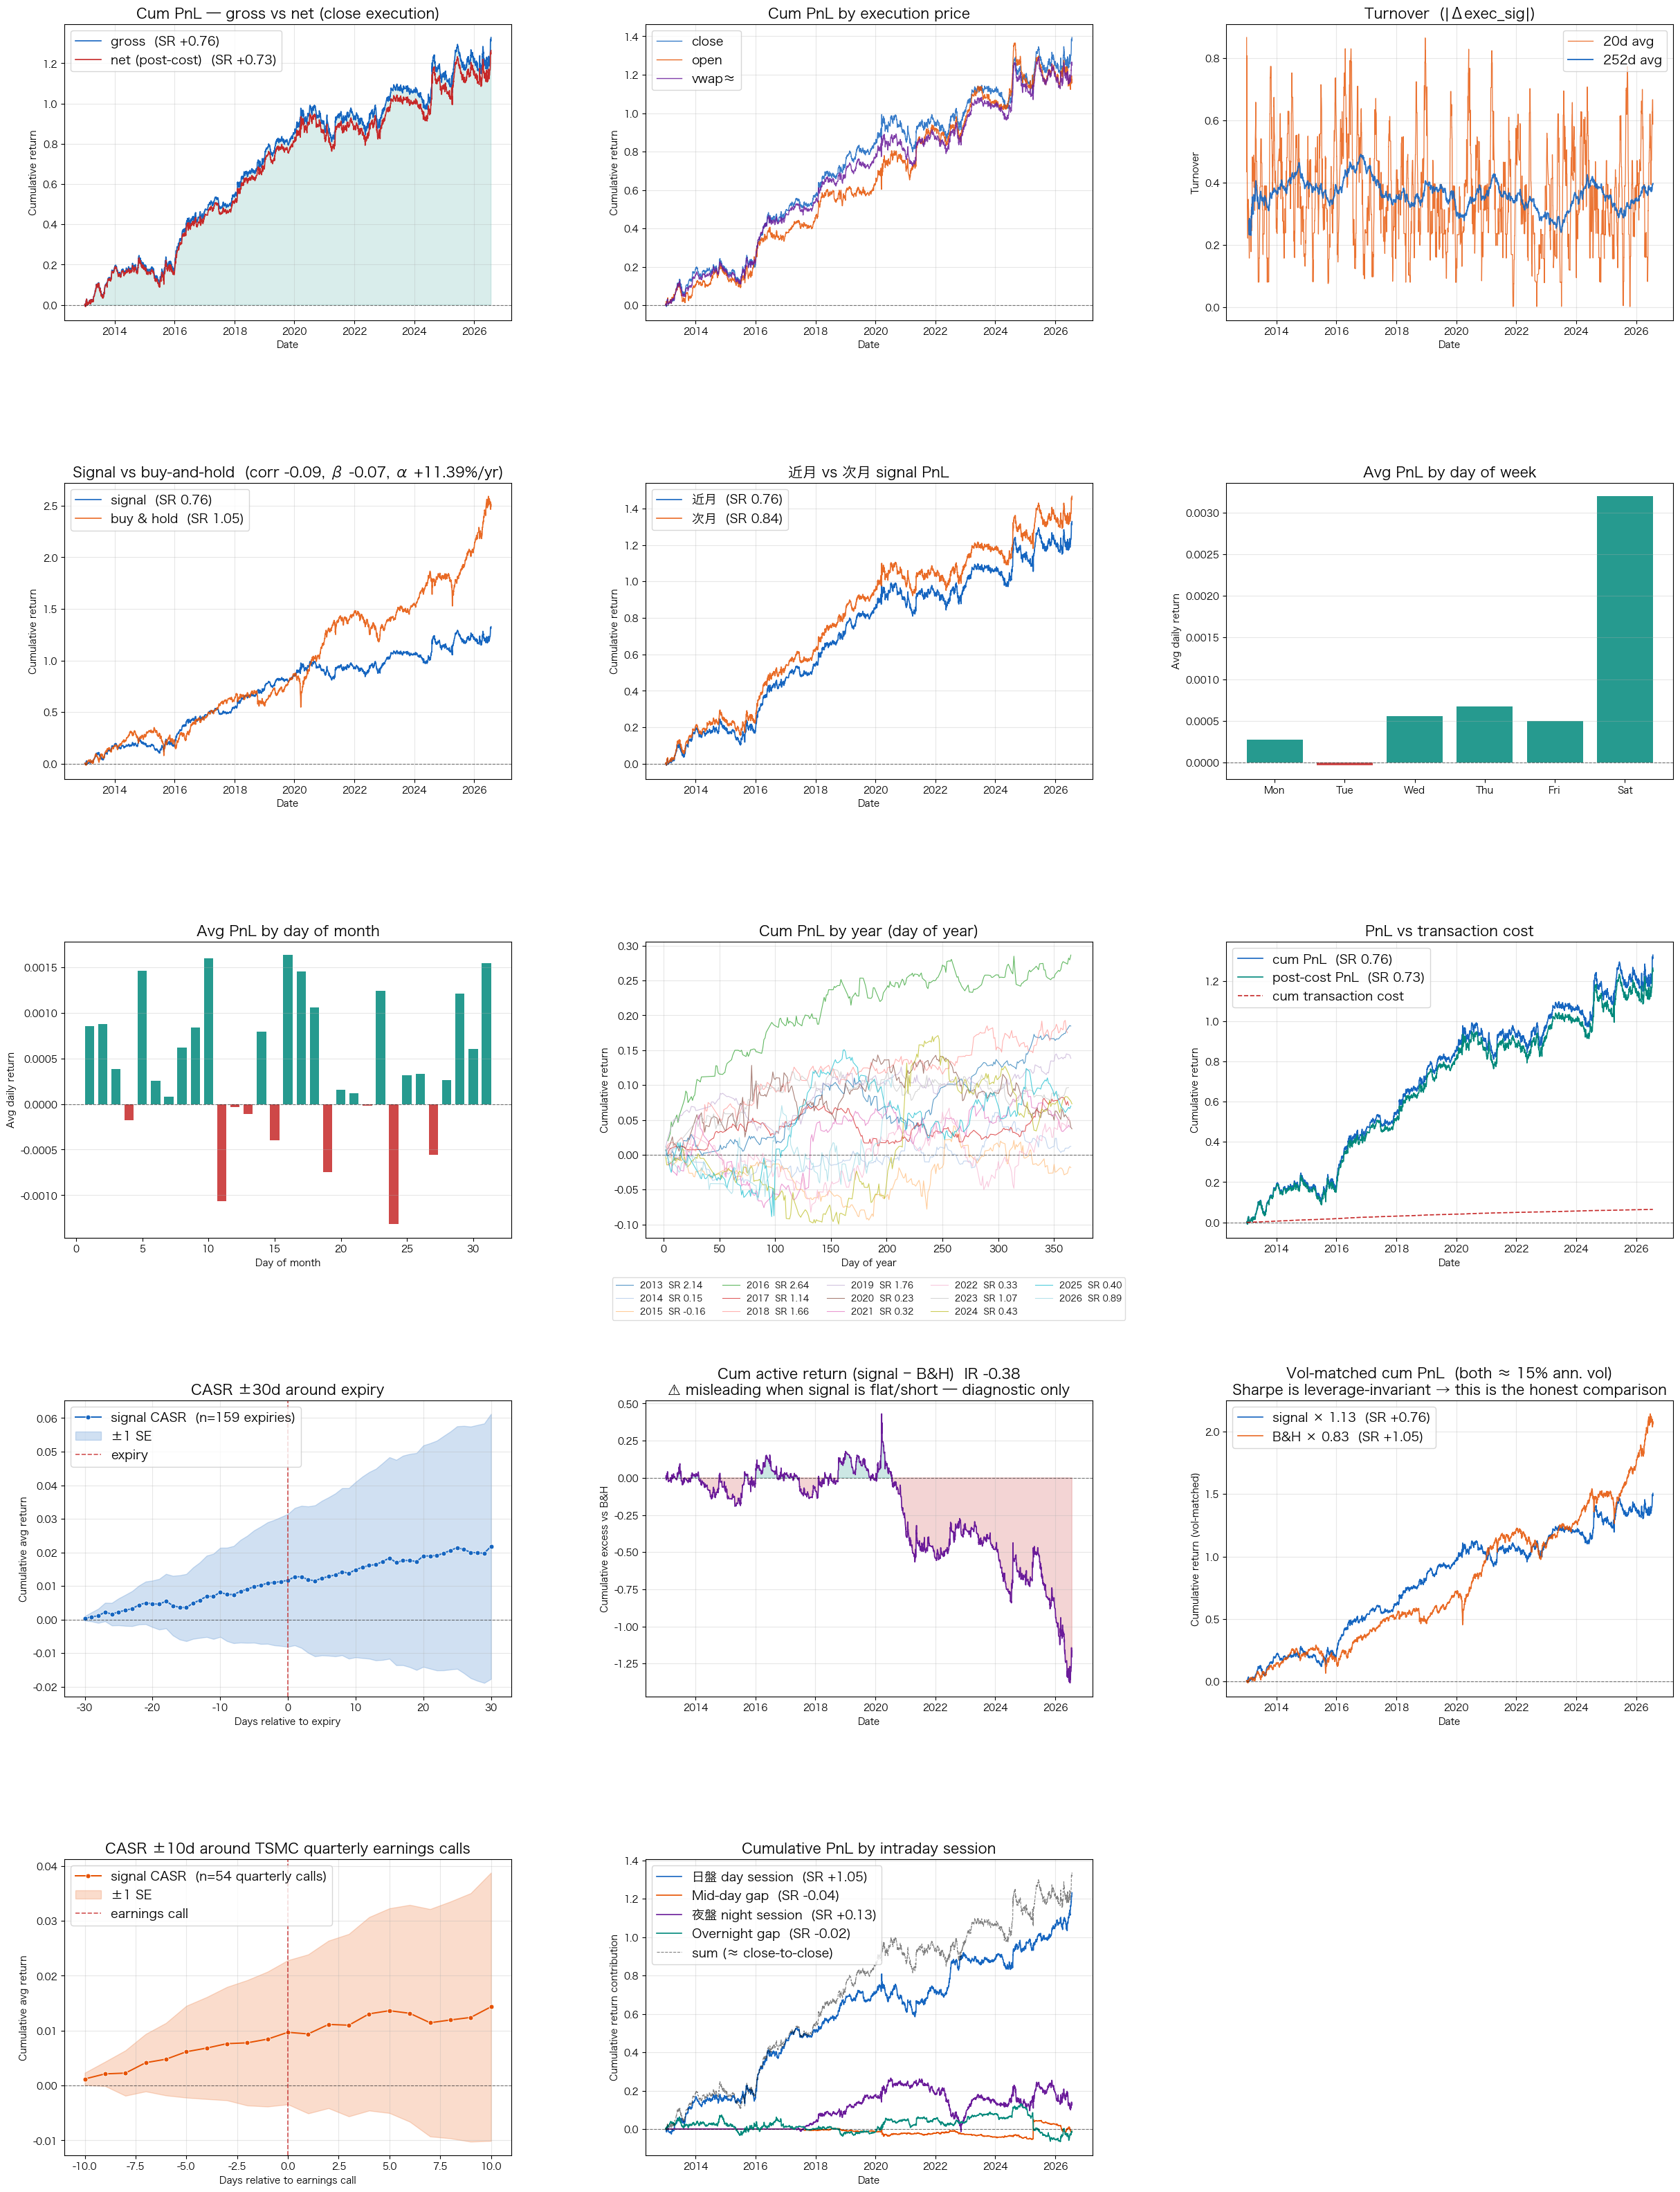

In [24]:
if len(diverse):
    ranked = diverse.sort_values("composite", ascending=False).index.tolist()
    sigs   = [SIGNED[k] for k in ranked]
    names  = [f"{k}|SR{r.loc[k,'SR_net']:+.2f}|SRoSR{r.loc[k,'SR_of_SR']:+.2f}|posY{r.loc[k,'pos_yr_pct']:.0f}%"
              for k in ranked]
    cta.SimulateAll(*sigs, names=names, asset="mtx", time_granularity="1d",
                    normalize=False, start_date=EVAL_START, end_date=EVAL_END)

    for k in ranked[:3]:
        row = r.loc[k]
        print("\n" + "="*100)
        print(f"  {k}    SR {row['SR_net']:+.2f}  |  SR_of_SR {row['SR_of_SR']:+.2f}  "
              f"|  pos_yr {row['pos_yr_pct']:.0f}%  |  worst_yr {row['yr_sr_min']:+.2f}  "
              f"|  max_dd {int(row['max_dd_days'])}d  |  α {row['alpha_ann_pct']:+.1f}%/yr")
        print("="*100)
        _ = cta.Simulate(SIGNED[k], asset="mtx", time_granularity="1d",
                         normalize=False, start_date=EVAL_START, end_date=EVAL_END)


## 9. Aggregate the top 4 US-signal winners

Four winners from four **different bases** (so the combined portfolio is truly independent alpha streams, not just re-slicings of the same idea):

| pick | base | interpretation |
|---|---|---|
| `log_ratio_level__pct_change_W120` | log(SOX/SPY) level | 120-day change in the semi-tilt level — slow rotation signal |
| `sox_agree_amp_N20__robust_z_W20`  | `sign(spy_ret_20)·(sox_ret_20/spy_ret_20)` | signed amplification — SOX leadership in SPY's direction |
| `sox_spy_rollcorr_W60__robust_z_W120` | 60d rolling corr(SOX_ret_1, SPY_ret_1) | correlation regime — high corr = risk-on |
| `sox_spy_ret_product_N5__pct_change_W20` | `SOX_ret_5 × SPY_ret_5` | directional agreement × combined magnitude |

Same aggregation methods as [`best_signals_aggregate.ipynb`](best_signals_aggregate.ipynb) § 8 — equal-weight (positions), vol-parity, and adaptive schemes for comparison.


In [25]:
# ── § 9.1  Pick winners + aggregate 6 different ways ──────────────────────
WINNER_NAMES = [
    "log_ratio_level__pct_change_W120",
    "sox_agree_amp_N20__robust_z_W20",
    "sox_spy_rollcorr_W60__robust_z_W120",
    "sox_spy_ret_product_N5__pct_change_W20",
]
# Sanity — all must be in SIGNED
missing = [n for n in WINNER_NAMES if n not in SIGNED]
if missing:
    raise KeyError(f"picks missing from SIGNED dict: {missing}")

WSIG = pd.DataFrame({n: SIGNED[n].reindex(ASSET.index) for n in WINNER_NAMES}
                    ).loc[EVAL_START:EVAL_END]

ret_srs  = ASSET["close"].pct_change()
cost_pct2 = 20.0 / (ASSET["close"] * 50.0) + 0.00002
def _pnl_of(sig):
    ex = sig.shift(2); return (ex*ret_srs) - ex.fillna(0).diff().abs()*cost_pct2
WPNL = pd.DataFrame({n: _pnl_of(WSIG[n]) for n in WSIG.columns}).loc[EVAL_START:EVAL_END]

# Combination methods
combos = {}
for n in WSIG.columns: combos[f"solo:{n}"] = WPNL[n]
combos["equal_positions"]  = _pnl_of(WSIG.mean(axis=1))
combos["equal_pnl"]        = WPNL.sum(axis=1) / len(WSIG.columns)
_vols = WPNL.std(); _w = (1/_vols)/(1/_vols).sum()
combos["vol_parity_static"] = (WPNL * _w).sum(axis=1)
roll_vol = WPNL.rolling(252, min_periods=60).std().shift(1)
w_roll   = 1.0/roll_vol.replace(0, np.nan); w_roll = w_roll.div(w_roll.sum(axis=1), axis=0)
combos["vol_parity_roll252"] = (WPNL * w_roll).sum(axis=1)
roll_sr = (WPNL.rolling(252, min_periods=60).mean()*np.sqrt(252)
           / WPNL.rolling(252, min_periods=60).std()).shift(1)
w_sr = roll_sr.clip(lower=0); _sm = w_sr.sum(axis=1).replace(0, np.nan)
w_sr = w_sr.div(_sm, axis=0)
combos["recent_sr_roll252"] = (WPNL * w_sr).sum(axis=1)

# Summary
def _sr(x):
    x=x.dropna(); return float(np.sqrt(252)*x.mean()/x.std()) if x.std()>0 else np.nan
def _max_dd_d(x):
    cum=x.cumsum(); dd=(cum-cum.cummax())<0
    if not dd.any(): return 0
    runs=dd.astype(int).groupby((dd!=dd.shift()).cumsum()).sum()
    return int(runs.max())
def _stats(pnl, label):
    a=pnl.dropna()
    if len(a)==0: return {"label":label,"SR":np.nan}
    ann_ret=a.mean()*252; ann_vol=a.std()*np.sqrt(252)
    dd=a.cumsum()-a.cumsum().cummax()
    yr=a.groupby(a.index.year).apply(lambda x:_sr(x)).dropna()
    return {"label":label,"SR":round(_sr(a),3),
            "ann_ret_%":round(ann_ret*100,2),"ann_vol_%":round(ann_vol*100,2),
            "calmar":round(ann_ret/abs(dd.min()),3) if dd.min()<0 else np.nan,
            "max_dd_d":_max_dd_d(a),
            "pos_yr_%":round((yr>0).mean()*100,1),
            "worst_yr_SR":round(yr.min(),2) if len(yr) else np.nan,
            "SR_of_SR":round(_sr(yr),3) if yr.std() else np.nan}

comb_stats = pd.DataFrame([_stats(v,k) for k,v in combos.items()]).set_index("label")
solo_mask = comb_stats.index.str.startswith("solo:")

print("=== § 9.1  Individual US-signal winners (baseline) ===")
display(comb_stats[solo_mask].round(3))
print("\n=== Aggregation methods, ranked by SR ===")
display(comb_stats[~solo_mask].sort_values("SR", ascending=False).round(3))

# 2026 YTD
print("\n=== 2026 YTD SR by aggregation method ===")
for k,v in combos.items():
    if k.startswith("solo:"): continue
    ytd = v.loc["2026-01-01":]
    print(f"  {k:24s}  2026 SR = {_sr(ytd):+.3f}   2026 ann ret = {ytd.mean()*252*100:+.2f}%")


=== § 9.1  Individual US-signal winners (baseline) ===


,SR,ann_ret_%,ann_vol_%,calmar,max_dd_d,pos_yr_%,worst_yr_SR,SR_of_SR
label,,,,,,,,
solo:log_ratio_level__pct_change_W120,0.727,10.38,14.28,0.515,401,92.9,-0.23,17.144
solo:sox_agree_amp_N20__robust_z_W20,0.760,6.83,8.99,0.305,318,92.9,-0.17,16.801
solo:sox_spy_rollcorr_W60__robust_z_W120,0.508,6.33,12.46,0.279,631,92.9,-0.30,19.669
solo:sox_spy_ret_product_N5__pct_change_W20,0.699,7.29,10.43,0.336,683,92.9,-0.20,15.129



=== Aggregation methods, ranked by SR ===


,SR,ann_ret_%,ann_vol_%,calmar,max_dd_d,pos_yr_%,worst_yr_SR,SR_of_SR
label,,,,,,,,
equal_positions,1.549,7.79,5.03,1.102,221,100.0,0.61,29.035
vol_parity_roll252,1.540,7.73,5.02,1.304,224,100.0,0.62,33.267
equal_pnl,1.533,7.71,5.03,1.087,221,100.0,0.59,28.668
vol_parity_static,1.497,7.54,5.03,1.006,225,100.0,0.67,30.323
recent_sr_roll252,0.576,4.48,7.78,0.184,933,71.4,-0.80,13.132



=== 2026 YTD SR by aggregation method ===
  equal_positions           2026 SR = +4.131   2026 ann ret = +30.56%
  equal_pnl                 2026 SR = +4.123   2026 ann ret = +30.50%
  vol_parity_static         2026 SR = +3.731   2026 ann ret = +28.61%
  vol_parity_roll252        2026 SR = +3.486   2026 ann ret = +28.26%
  recent_sr_roll252         2026 SR = +2.306   2026 ann ret = +31.77%


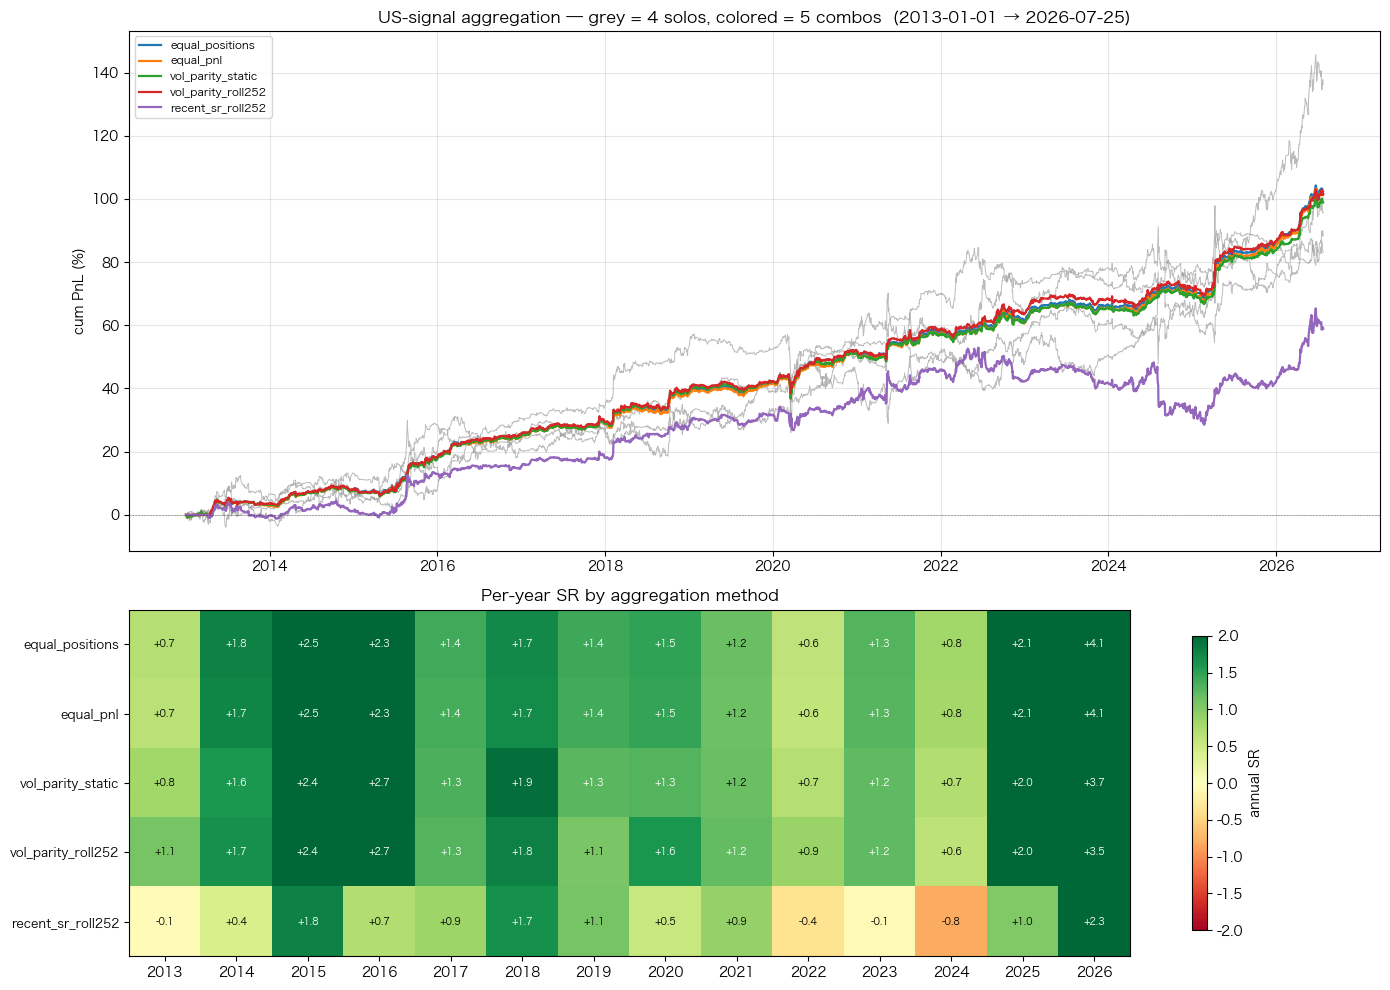

In [26]:
# ── § 9.2  Cum PnL comparison + per-year SR heatmap ───────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios":[3,2]})

ax = axes[0]
for n in WSIG.columns:
    ax.plot(WPNL[n].cumsum()*100, lw=0.7, color="#a0a0a0", alpha=0.7)
palette = plt.cm.tab10.colors; i=0
for k,v in combos.items():
    if k.startswith("solo:"): continue
    ax.plot(v.cumsum()*100, lw=1.6, color=palette[i%10], label=k); i+=1
ax.set_ylabel("cum PnL (%)"); ax.axhline(0, color="black", lw=0.4, ls="--", alpha=0.5)
ax.set_title(f"US-signal aggregation — grey = 4 solos, colored = 5 combos  ({EVAL_START} → {EVAL_END})")
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)

# Per-year SR heatmap
combo_yr = {}
for k,v in combos.items():
    if k.startswith("solo:"): continue
    a = v.dropna()
    combo_yr[k] = a.groupby(a.index.year).apply(lambda x:_sr(x))
ydf = pd.DataFrame(combo_yr).T
ydf = ydf.loc[:, ydf.columns >= 2013]

ax = axes[1]
im = ax.imshow(ydf.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(ydf.columns))); ax.set_xticklabels(ydf.columns)
ax.set_yticks(range(len(ydf))); ax.set_yticklabels(ydf.index, fontsize=9)
for i in range(ydf.shape[0]):
    for j in range(ydf.shape[1]):
        v = ydf.values[i,j]
        if np.isnan(v): continue
        ax.text(j,i,f"{v:+.1f}", ha="center",va="center",
                fontsize=7, color="white" if abs(v)>1.2 else "black")
ax.set_title("Per-year SR by aggregation method")
plt.colorbar(im, ax=ax, shrink=0.85, label="annual SR")
plt.tight_layout(); plt.show()


  us_signal_combo_eq  (equal-weight combo of 4 US-derived winners)


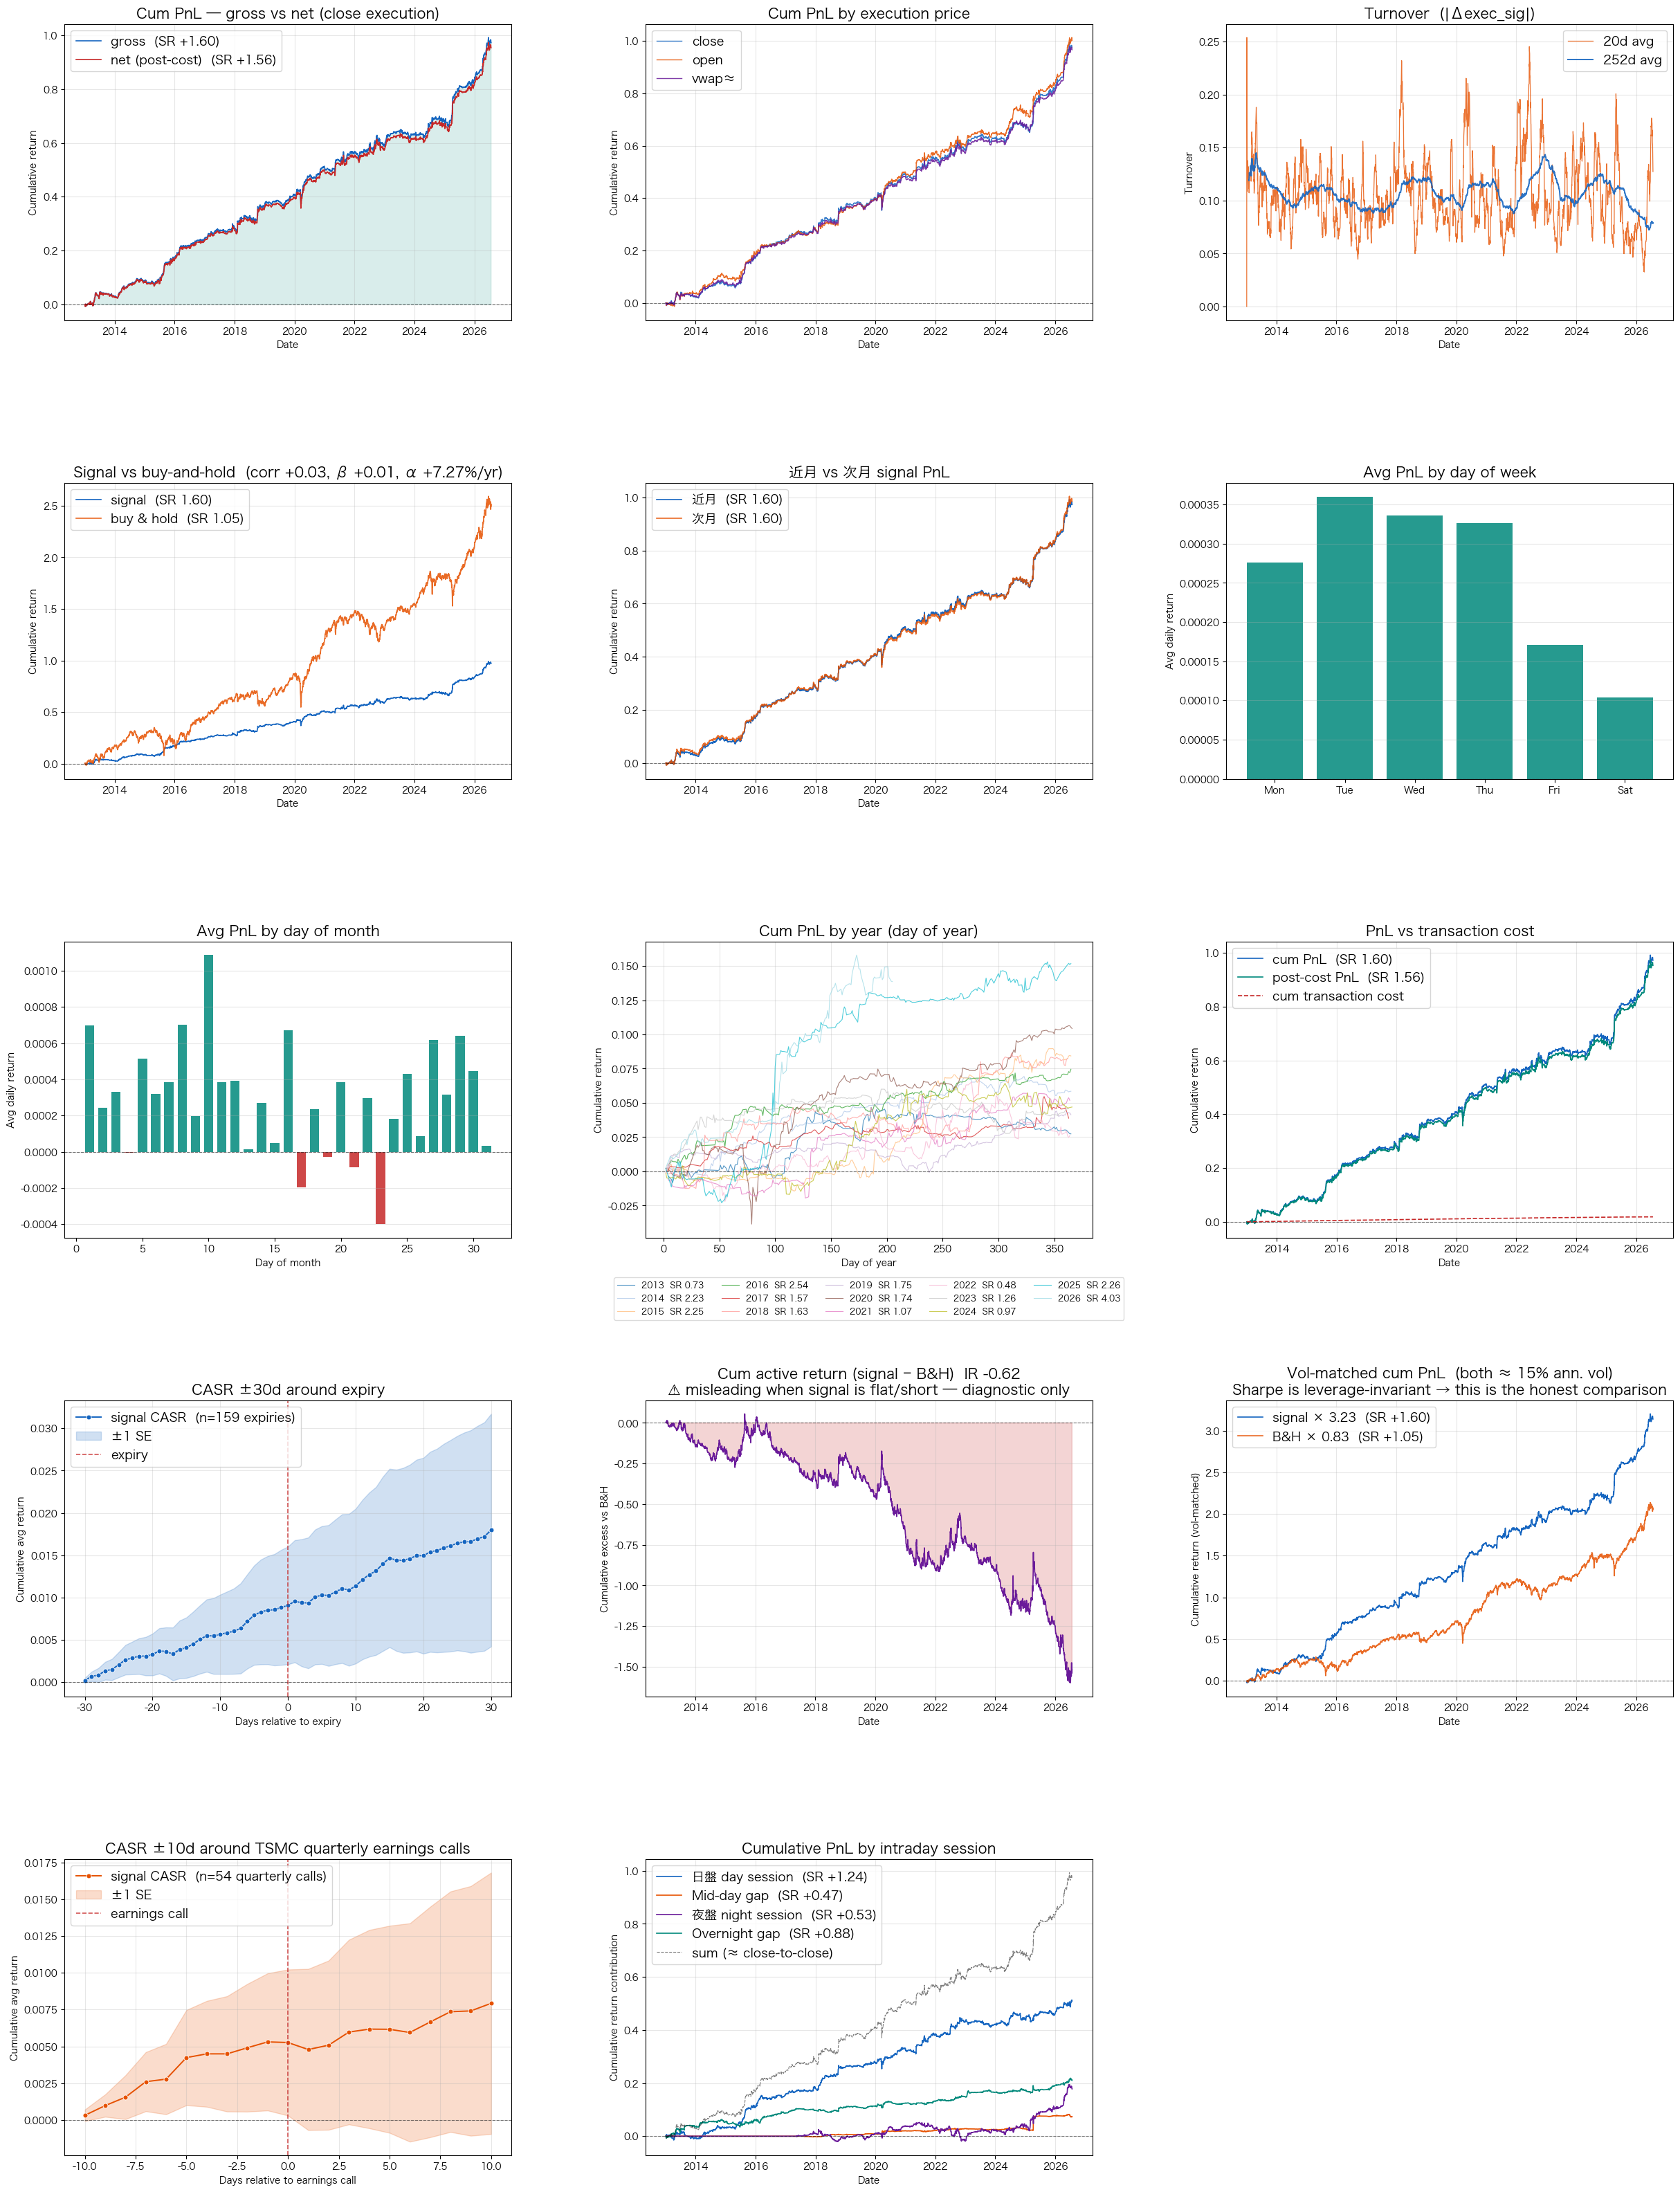


  simulate_by_dollars — NT$20M account (MTX 2026 notional ≈ NT$2.2M/contract)


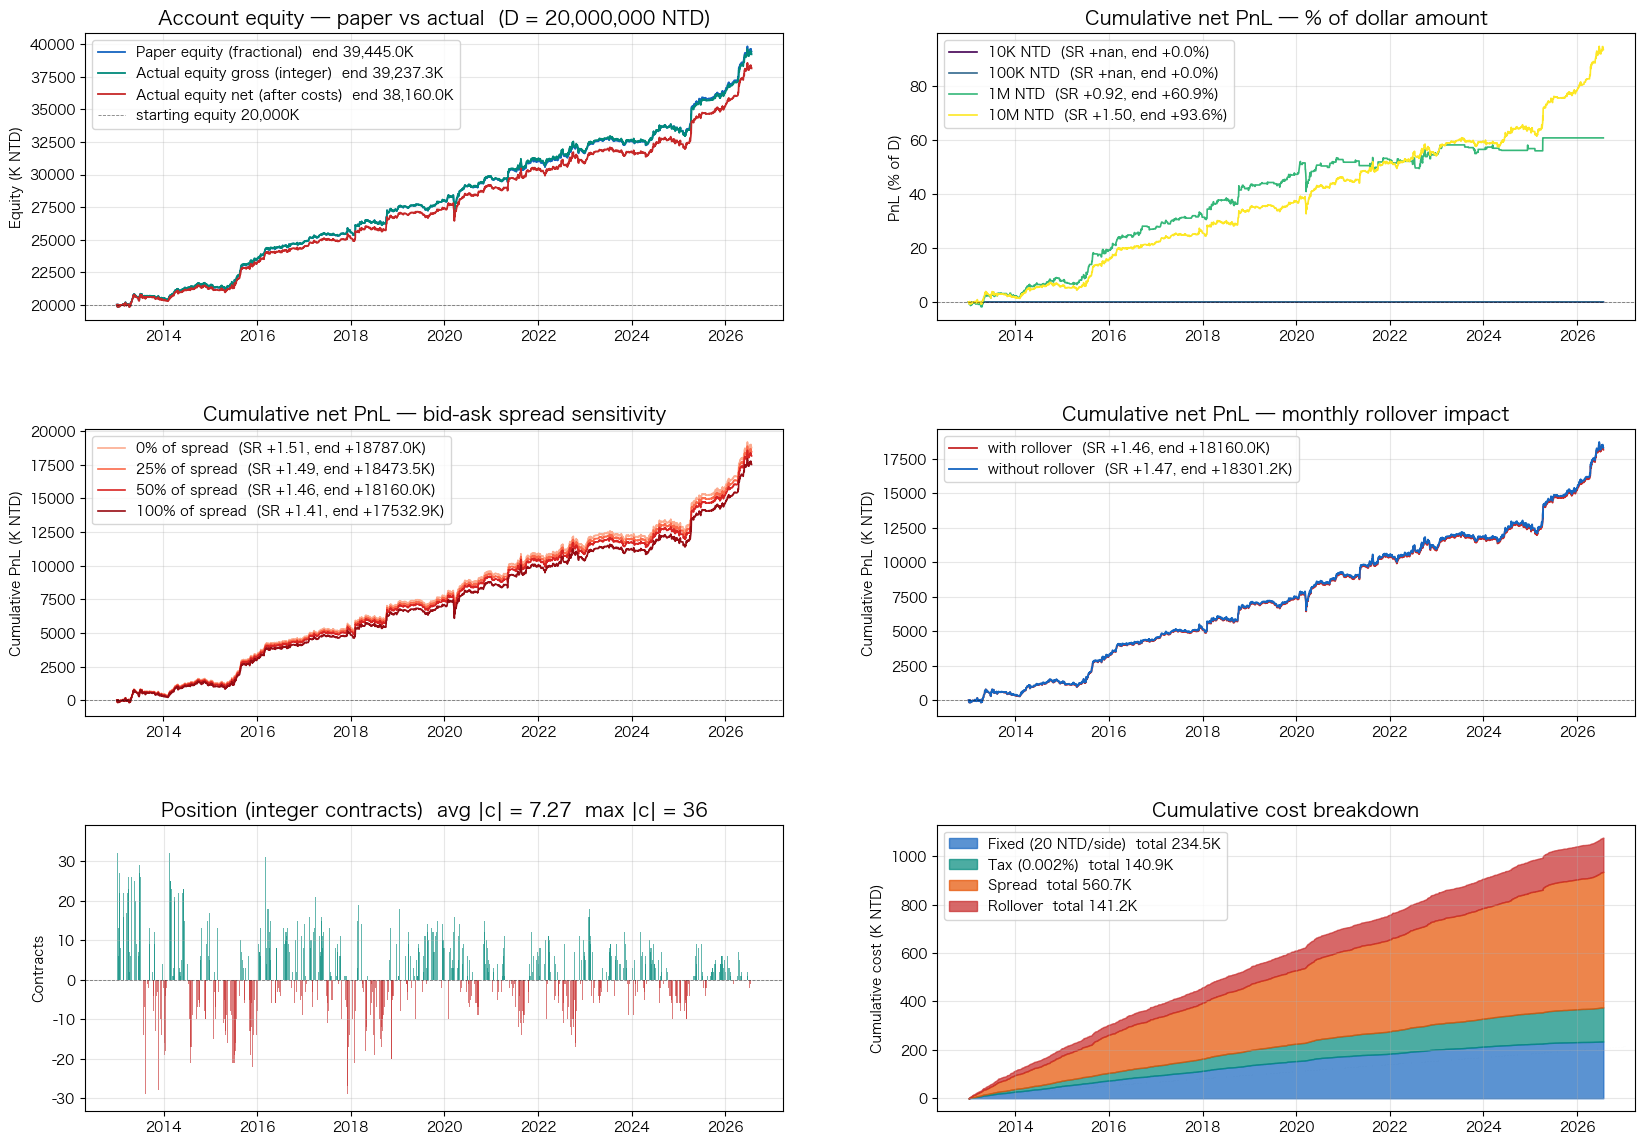

In [27]:
# ── § 9.3  Simulate + simulate_by_dollars on the winning combo ────────────
# Use equal_positions — it wins on SR and stays interpretable.
# MTX contract notional at 2026 prices ≈ NT$2.2 M/contract, so use a
# NT$20 M account to give the strategy room to size up (see best_signals_aggregate.ipynb
# § 8 note about $1M being too small on 2026 MTX).

combined_signal = np.tanh(WSIG.mean(axis=1)).rename("us_signal_combo_eq")

print("="*100)
print(f"  us_signal_combo_eq  (equal-weight combo of 4 US-derived winners)")
print("="*100)
_ = cta.Simulate(combined_signal, asset="mtx", time_granularity="1d",
                 normalize=False, start_date=EVAL_START, end_date=EVAL_END)

print("\n" + "="*100)
print(f"  simulate_by_dollars — NT$20M account (MTX 2026 notional ≈ NT$2.2M/contract)")
print("="*100)
_ = cta.simulate_by_dollars(combined_signal, dollar_amount=20_000_000,
                             asset="mtx", time_granularity="1d",
                             normalize=False,
                             start_date=EVAL_START, end_date=EVAL_END)


## 10. Extend to SOX × TAIEX and TAIEX × SPY

Same idea as § 2-§ 4 (SOX vs SPY) but now testing:
- **SOX × TAIEX** — semi (US) vs Taiwan broad — is there predictive info in the semi-vs-domestic-benchmark spread?
- **TAIEX × SPY** — Taiwan broad vs US broad — does TW/US relative performance predict MTX?

### PIT alignment
- **SOX** close on US date `U` → labeled at TW date `U+1` (via `cta.load_us_index_tw` with `pit_lag_days=1`)
- **SPY** same
- **TAIEX** close on TW date `D` is known at ~13:45 TPE `D`. Loaded directly (no shift), so `taiex[D]` = TWSE 發行量加權 close on `D`. Usable at TW date `D+1` open onwards — matches `cta.Simulate`'s `signal.shift(2)` convention.

Any signal built from **combinations of these three** (SOX, SPY, TAIEX) is PIT-safe when passed through `cta.Simulate` unchanged.

### Base families added (same 4 canonical shapes as the SOX × SPY families)

For each pair `(A, B)` in `{(SOX, TAIEX), (TAIEX, SPY)}`, we build:

| family | formula | interpretation |
|---|---|---|
| `A_over_B_chg_ratio_N` | `(A − Lag_N(A)) / (B − Lag_N(B))` | amplification of A's move vs B in absolute points |
| `A_agree_amp_B_N` | `sign(B_ret_N) × (A_ret_N / B_ret_N)` | signed amplification — "how much did A lead B" — **won for SOX vs SPY** |
| `A_B_ret_product_N` | `A_ret_N × B_ret_N` | directional agreement × combined magnitude |
| `log_ratio_A_B_N` | `log(A/B) − shifted` | slow rotation between A and B |

Plus individual returns, rolling correlation, and vol ratio for completeness.


In [28]:
# ── § 10.1  Load TAIEX + build SOX×TAIEX and TAIEX×SPY base families ─────

import csv
from pathlib import Path

def load_taiex_spot():
    """Same loader as carry_basis_signals.ipynb — TWSE 發行量加權 close per day.
    Returns pd.Series indexed by TW calendar date."""
    root = Path("/Users/hsureggie/coding/Research/QuantResearch/Cache/tw/twse")
    rows = []
    for path in sorted(root.rglob("twse_*.csv")):
        ymd = path.stem[-8:]
        try:
            with open(path, encoding="utf-8-sig") as f:
                for row in csv.reader(f):
                    if row and "發行量加權" in row[0]:
                        rows.append((pd.Timestamp(f"{ymd[:4]}-{ymd[4:6]}-{ymd[6:8]}"),
                                     float(row[1].replace(",","").strip())))
                        break
        except Exception:
            continue
    return (pd.DataFrame(rows, columns=["date","taiex"])
              .set_index("date").sort_index()["taiex"])

taiex_close = load_taiex_spot().reindex(ASSET.index).astype(float)
print(f"TAIEX close   n_valid={taiex_close.notna().sum():>5d}   "
      f"first={taiex_close.dropna().index[0].date()}   "
      f"last={taiex_close.dropna().index[-1].date()}")

# ── Family builder — parameterized by (A, B, name) so we can apply to
#    (SOX, TAIEX) and (TAIEX, SPY) with identical shape ────────────────────
def _build_pair_bases(A_close, B_close, A_name, B_name):
    """Return dict of base signals for pair (A, B)."""
    out = {}
    A_r1 = A_close.pct_change(1); B_r1 = B_close.pct_change(1)

    # Individual returns
    for N in [1, 5, 20]:
        out[f"{A_name}_ret{N}"]          = A_close.pct_change(N)
        out[f"{B_name}_ret{N}"]          = B_close.pct_change(N)
        out[f"{A_name}_minus_{B_name}_ret{N}"] = A_close.pct_change(N) - B_close.pct_change(N)

    # Log ratio and its changes
    lr = np.log(A_close / B_close)
    out[f"log_ratio_{A_name}_{B_name}_level"] = lr
    for N in [5, 20, 60]:
        out[f"log_ratio_{A_name}_{B_name}_chg{N}"] = lr.diff(N)

    # Rolling β-neutralized A residual
    def _ra(y, x, W):
        cv = y.rolling(W, min_periods=max(20, W//3)).cov(x)
        vv = x.rolling(W, min_periods=max(20, W//3)).var().replace(0, np.nan)
        return y - (cv/vv) * x
    for W in [60, 120]:
        out[f"{A_name}_alpha_vs_{B_name}_ret1_W{W}"] = _ra(A_r1, B_r1, W)

    # Rolling correlation
    for W in [20, 60]:
        out[f"{A_name}_{B_name}_rollcorr_W{W}"] = A_r1.rolling(
            W, min_periods=max(10, W//3)).corr(B_r1)

    # Vol ratio
    for W in [20, 60]:
        vA = A_r1.rolling(W, min_periods=max(10, W//3)).std()
        vB = B_r1.rolling(W, min_periods=max(10, W//3)).std().replace(0, np.nan)
        out[f"{A_name}_{B_name}_volratio_W{W}"] = vA / vB

    # Ratio-of-changes families (the winners from SOX × SPY analysis)
    for N in [5, 20, 60]:
        A_chg = A_close - A_close.shift(N)
        B_chg = B_close - B_close.shift(N)
        # Denominator floor scales with B's typical magnitude (~0.05% of level)
        floor = 0.0005 * B_close.abs().rolling(120, min_periods=20).mean().shift(1)
        denom = B_chg.where(B_chg.abs() > floor, np.nan)
        out[f"{A_name}_over_{B_name}_chg_ratio_N{N}"] = (A_chg / denom).clip(-20, 20)

    for N in [5, 20, 60]:
        r_A = A_close.pct_change(N); r_B = B_close.pct_change(N)
        denom = r_B.where(r_B.abs() > 0.003, np.nan)
        out[f"{A_name}_over_{B_name}_ret_ratio_N{N}"] = (r_A / denom).clip(-10, 10)

    for N in [5, 20, 60]:
        out[f"{A_name}_{B_name}_ret_product_N{N}"] = (
            A_close.pct_change(N) * B_close.pct_change(N))

    for N in [5, 20, 60]:
        r_A = A_close.pct_change(N); r_B = B_close.pct_change(N)
        denom = r_B.where(r_B.abs() > 0.003, np.nan)
        out[f"{A_name}_agree_amp_{B_name}_N{N}"] = (np.sign(r_B) * (r_A / denom)).clip(-10, 10)

    return out

# Build the two new pair pools
BASE_SOX_TAIEX  = _build_pair_bases(sox_close, taiex_close, "sox",  "taiex")
BASE_TAIEX_SPY  = _build_pair_bases(taiex_close, spy_close, "taiex","spy")

print(f"\n  SOX × TAIEX  bases: {len(BASE_SOX_TAIEX)}")
print(f"  TAIEX × SPY  bases: {len(BASE_TAIEX_SPY)}")

# Merge everything into one dict with source prefix
BASE_NEW = {}
for n, s in BASE_SOX_TAIEX.items():  BASE_NEW[f"ST__{n}"] = s
for n, s in BASE_TAIEX_SPY.items():  BASE_NEW[f"TS__{n}"] = s
print(f"  combined new bases: {len(BASE_NEW)}")


TAIEX close   n_valid= 4285   first=2009-01-05   last=2026-07-24

  SOX × TAIEX  bases: 31
  TAIEX × SPY  bases: 31
  combined new bases: 62


In [29]:
# ── § 10.2  Apply the same 10-method × 4-window palette ──────────────────

NORM_NEW = {}
for k, s in BASE_NEW.items():
    for W in WINDOWS:
        for mn, fn in METHODS.items():
            if mn == "raw" and W != WINDOWS[0]: continue
            try:
                v = fn(s, W).replace([np.inf,-np.inf], np.nan)
                key = f"{k}__raw" if mn == "raw" else f"{k}__{mn}_W{W}"
                NORM_NEW[key] = v.rename(key)
            except Exception:
                pass

NORM_NEW = {n: cta.normalize_signal(s.fillna(0.0), method="tanh", window=252, force=True).rename(n)
            for n, s in NORM_NEW.items()}
print(f"{len(BASE_NEW)} new bases × {len(METHODS)} methods × {len(WINDOWS)} windows = {len(NORM_NEW)} variants")

# Merge with existing SOX×SPY NORM pool so gates run over EVERYTHING together
# (keeps existing SOX×SPY results in scope for comparison)
NORM_ALL = {**NORM, **NORM_NEW}
print(f"combined pool size (SOX×SPY + new pairs): {len(NORM_ALL)}")


62 new bases × 10 methods × 4 windows = 2294 variants
combined pool size (SOX×SPY + new pairs): 3515


In [30]:
# ── § 10.3  Auto-flip + tiered gates + composite ranking on FULL pool ────

_tbl_flip = cta.batch_signal_stats(NORM_ALL, ASSET, start=EVAL_START, end=EVAL_END, auto_flip=True)
SIGNS_ALL  = {n: int(_tbl_flip.loc[n,"sign"]) for n in _tbl_flip.index}
SIGNED_ALL = {n: (NORM_ALL[n] * SIGNS_ALL[n]).rename(n) for n in NORM_ALL}

r_all = cta.batch_signal_stats(SIGNED_ALL, ASSET, start=EVAL_START, end=EVAL_END, auto_flip=False)
r_all["pos_yr_pct"] = (r_all["positive_years"] * 100).round(1)
def _pair_of(nm):
    if nm.startswith("ST__"): return "SOX_TAIEX"
    if nm.startswith("TS__"): return "TAIEX_SPY"
    return "SOX_SPY"
r_all["pair"] = r_all.index.map(_pair_of)
r_all["base"] = r_all.index.map(lambda n: n.rsplit("__", 1)[0])

STRICT_ALL  = ((r_all["beta"].abs()<0.15) & (r_all["SR_of_SR"]>0.6) & (r_all["pos_yr_pct"]>=65) &
               (r_all["yr_sr_min"]>-1.5)   & (r_all["max_dd_days"]<400) & (r_all["SR_net"]>0.5) &
               (r_all["n_years"]>=5))
RELAXED_ALL = ((r_all["beta"].abs()<0.25) & (r_all["SR_of_SR"]>0.5) & (r_all["pos_yr_pct"]>=60) &
               (r_all["yr_sr_min"]>-1.5)   & (r_all["max_dd_days"]<800) & (r_all["SR_net"]>0.4) &
               (r_all["n_years"]>=5))

print(f"=== Combined pool ({len(r_all)} variants) ===")
print(f"  STRICT : {STRICT_ALL.sum():4d}    RELAXED: {RELAXED_ALL.sum():4d}")
print(f"\n  Passers by pair:")
for pair in ["SOX_SPY","SOX_TAIEX","TAIEX_SPY"]:
    sub = r_all[r_all["pair"]==pair]
    ns = STRICT_ALL[sub.index].sum() if len(sub) else 0
    nr = RELAXED_ALL[sub.index].sum() if len(sub) else 0
    print(f"    {pair:12s} — STRICT {ns:3d}    RELAXED {nr:3d}    (of {len(sub)} variants)")

# Composite ranking on RELAXED pool
p_all = r_all[RELAXED_ALL].copy()
if len(p_all):
    p_all["s_srsr"] = p_all["SR_of_SR"].rank(pct=True)
    p_all["s_posy"] = p_all["pos_yr_pct"].rank(pct=True)
    p_all["s_wrst"] = p_all["yr_sr_min"].rank(pct=True)
    p_all["s_dd"]   = (-p_all["max_dd_days"]).rank(pct=True)
    p_all["s_sr"]   = p_all["SR_net"].rank(pct=True)
    p_all["composite"] = (0.45*p_all["s_srsr"] + 0.25*p_all["s_posy"] + 0.15*p_all["s_wrst"] +
                           0.10*p_all["s_dd"]   + 0.05*p_all["s_sr"])
    diverse_all = p_all.sort_values(["base","composite"], ascending=[True,False]).groupby("base").head(2)
    diverse_all = diverse_all.sort_values("composite", ascending=False)
    show = ["pair","base","SR_net","SR_of_SR","pos_yr_pct","yr_sr_min","max_dd_days",
            "beta","alpha_ann_pct","n_years","composite"]
    print(f"\n=== Top 25 across ALL pairs by composite (diversified top-2 per base) ===\n")
    display(diverse_all.head(25)[show].round(3))


=== Combined pool (3515 variants) ===
  STRICT :    6    RELAXED:  110

  Passers by pair:
    SOX_SPY      — STRICT   6    RELAXED  49    (of 1221 variants)
    SOX_TAIEX    — STRICT   0    RELAXED  32    (of 1147 variants)
    TAIEX_SPY    — STRICT   0    RELAXED  29    (of 1147 variants)

=== Top 25 across ALL pairs by composite (diversified top-2 per base) ===



,pair,base,SR_net,SR_of_SR,pos_yr_pct,yr_sr_min,max_dd_days,beta,alpha_ann_pct,n_years,composite
signal,,,,,,,,,,,
sox_agree_amp_N20__robust_z_W20,SOX_SPY,sox_agree_amp_N20,0.765,1.062,92.9,-0.172,318,-0.046,7.566,14,0.973
log_ratio_level__pct_change_W120,SOX_SPY,log_ratio_level,0.733,1.117,92.9,-0.092,401,-0.088,11.798,14,0.972
sox_agree_amp_N20__dev_tanh_W10,SOX_SPY,sox_agree_amp_N20,0.749,1.202,92.9,-0.043,603,-0.072,11.196,14,0.928
sox_spy_rollcorr_W60__robust_z_W120,SOX_SPY,sox_spy_rollcorr_W60,0.512,1.253,92.9,-0.301,631,0.098,4.905,14,0.892
ST__sox_taiex_ret_product_N5__pct_change_W20,SOX_TAIEX,ST__sox_taiex_ret_product_N5,0.633,0.996,85.7,-0.459,509,0.105,5.535,14,0.852
sox_spy_ret_product_N5__pct_change_W20,SOX_SPY,sox_spy_ret_product_N5,0.700,0.956,92.9,-0.196,683,0.084,6.036,14,0.851
sox_spy_rollcorr_W60__selfz_W120,SOX_SPY,sox_spy_rollcorr_W60,0.547,1.059,85.7,-0.449,631,0.109,5.064,14,0.827
log_ratio_level__pct_change_W10,SOX_SPY,log_ratio_level,0.533,1.007,85.7,-0.878,479,-0.204,9.891,14,0.796
TS__taiex_over_spy_chg_ratio_N60__pct_change_W120,TAIEX_SPY,TS__taiex_over_spy_chg_ratio_N60,0.605,0.936,78.6,-0.311,400,-0.024,6.733,14,0.796


=== Top 15 NEW-pair signals (61 passers, diversified) ===



,pair,base,SR_net,SR_of_SR,pos_yr_pct,yr_sr_min,max_dd_days,beta,alpha_ann_pct,composite
signal,,,,,,,,,,
ST__sox_taiex_ret_product_N5__pct_change_W20,SOX_TAIEX,ST__sox_taiex_ret_product_N5,0.633,0.996,85.7,-0.459,509,0.105,5.535,0.940
TS__taiex_over_spy_chg_ratio_N60__pct_change_W120,TAIEX_SPY,TS__taiex_over_spy_chg_ratio_N60,0.605,0.936,78.6,-0.311,400,-0.024,6.733,0.905
TS__taiex_spy_ret_product_N60__pct_change_W120,TAIEX_SPY,TS__taiex_spy_ret_product_N60,0.524,0.802,78.6,-0.690,663,-0.141,8.665,0.791
ST__sox_taiex_ret_product_N60__robust_z_W120,SOX_TAIEX,ST__sox_taiex_ret_product_N60,0.454,0.790,85.7,-1.125,610,-0.029,5.852,0.775
TS__taiex_spy_ret_product_N60__selfz_W120,TAIEX_SPY,TS__taiex_spy_ret_product_N60,0.510,0.702,78.6,-0.827,496,-0.041,7.150,0.765
TS__taiex_agree_amp_spy_N60__robust_z_W120,TAIEX_SPY,TS__taiex_agree_amp_spy_N60,0.453,0.746,78.6,-0.465,730,-0.192,8.159,0.756
ST__log_ratio_sox_taiex_chg20__selfz_tanh_W20,SOX_TAIEX,ST__log_ratio_sox_taiex_chg20,0.473,0.720,85.7,-1.239,547,-0.087,7.501,0.749
ST__sox_minus_taiex_ret20__selfz_tanh_W20,SOX_TAIEX,ST__sox_minus_taiex_ret20,0.458,0.711,85.7,-1.254,547,-0.084,7.227,0.730
ST__sox_minus_taiex_ret20__dev_tanh_W20,SOX_TAIEX,ST__sox_minus_taiex_ret20,0.448,0.700,85.7,-1.129,547,-0.084,7.007,0.730


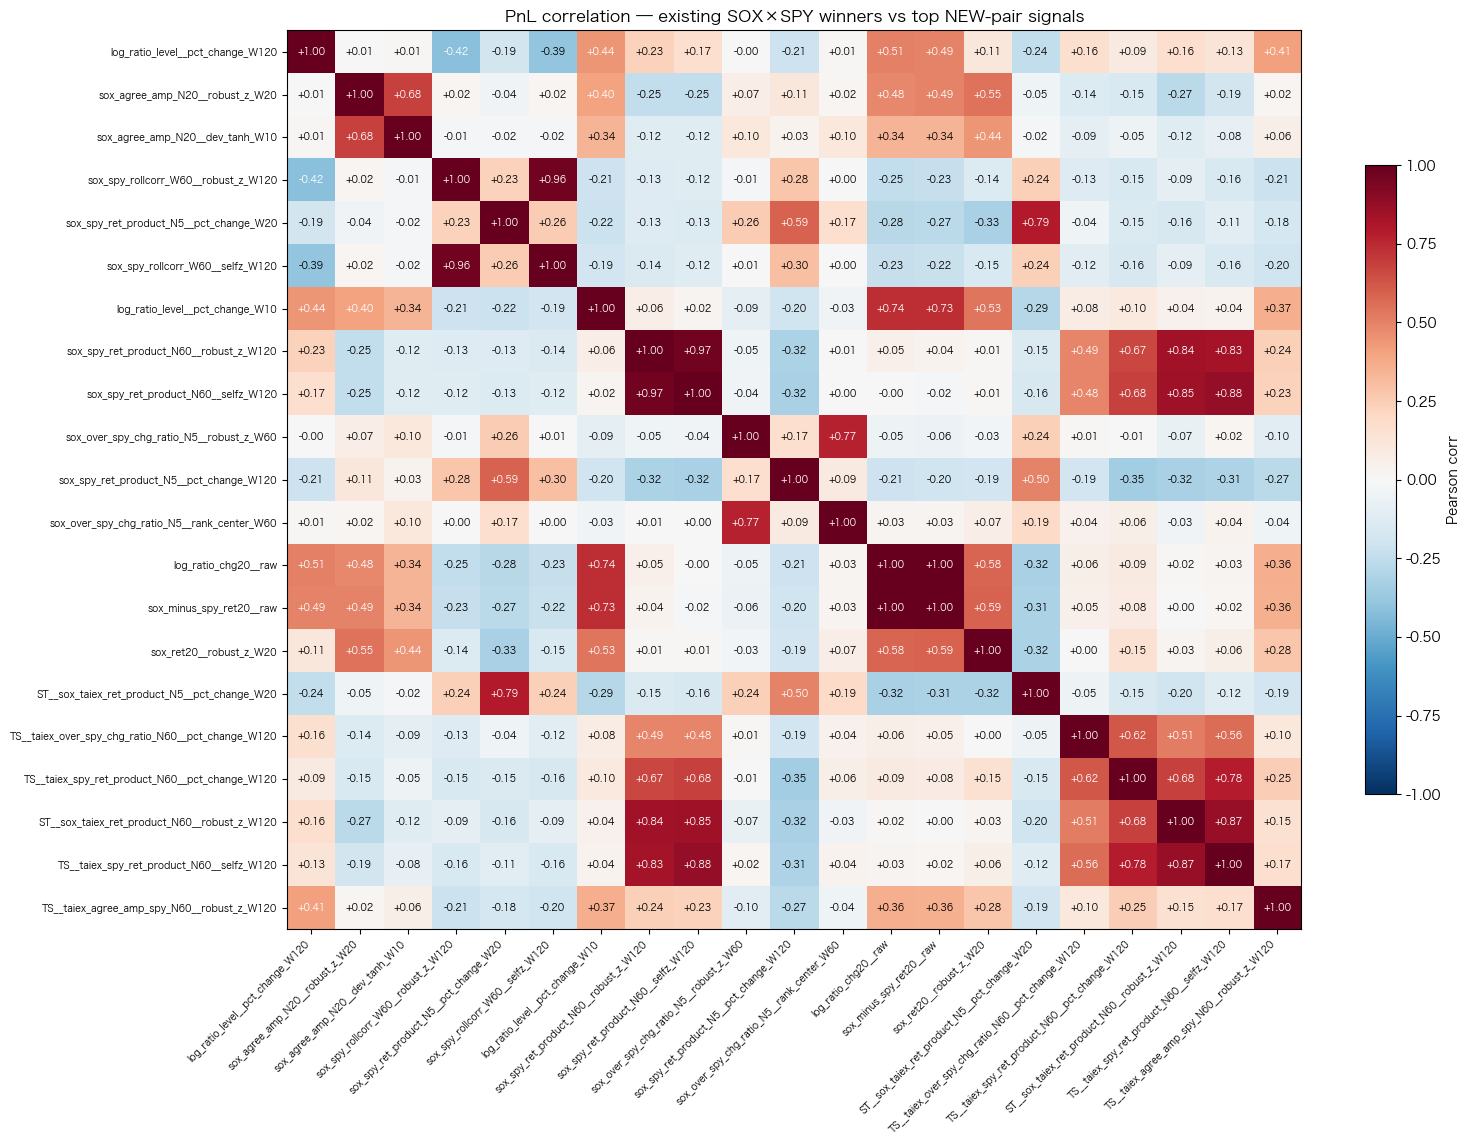


=== Cross-correlations: existing SOX×SPY winners × top NEW-pair winners ===
  mean |cross corr|: 0.206
  max  |cross corr|: 0.877
  59 / 90 pairs are |corr|<0.20 (diversifying)


In [31]:
# ── § 10.4  Best NEW-pair signals only (excluding SOX×SPY) ────────────────

new_only = r_all[(r_all["pair"] != "SOX_SPY") & RELAXED_ALL].copy()
if len(new_only):
    new_only["s_srsr"]=new_only["SR_of_SR"].rank(pct=True)
    new_only["s_posy"]=new_only["pos_yr_pct"].rank(pct=True)
    new_only["s_wrst"]=new_only["yr_sr_min"].rank(pct=True)
    new_only["s_dd"]  =(-new_only["max_dd_days"]).rank(pct=True)
    new_only["s_sr"]  =new_only["SR_net"].rank(pct=True)
    new_only["composite"]=(0.45*new_only["s_srsr"]+0.25*new_only["s_posy"]+0.15*new_only["s_wrst"]+
                            0.10*new_only["s_dd"]  +0.05*new_only["s_sr"])
    d_new = new_only.sort_values(["base","composite"],ascending=[True,False]).groupby("base").head(2)
    d_new = d_new.sort_values("composite", ascending=False)
    show = ["pair","base","SR_net","SR_of_SR","pos_yr_pct","yr_sr_min","max_dd_days",
            "beta","alpha_ann_pct","composite"]
    print(f"=== Top 15 NEW-pair signals ({len(new_only)} passers, diversified) ===\n")
    display(d_new.head(15)[show].round(3))

# Are the new-pair winners CORRELATED with the existing SOX×SPY winners?
# Compute PnL correlation matrix over: (existing SOX×SPY winners) ∪ (top NEW winners)
if 'diverse' in dir() and len(diverse) and len(new_only):
    existing_names = list(diverse.index)
    new_top = d_new.head(6).index.tolist()
    inspect = existing_names + new_top
    ret_srs   = ASSET["close"].pct_change()
    cost_pct2 = 20.0/(ASSET["close"]*50.0) + 0.00002
    pnl_panel = {}
    for nm in inspect:
        sig = SIGNED_ALL[nm]
        ex  = sig.shift(2)
        pnl_panel[nm] = ((ex*ret_srs) - ex.fillna(0).diff().abs()*cost_pct2).loc[EVAL_START:EVAL_END]
    pnl_df = pd.DataFrame(pnl_panel).dropna(how="all")
    corr = pnl_df.corr()

    fig, ax = plt.subplots(figsize=(max(7, len(corr)*0.75), max(6, len(corr)*0.55)))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=7)
    for i in range(len(corr)):
        for j in range(len(corr)):
            v = corr.values[i,j]
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                    color="white" if abs(v)>0.4 else "black", fontsize=7)
    ax.set_title("PnL correlation — existing SOX×SPY winners vs top NEW-pair signals")
    plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson corr")
    plt.tight_layout(); plt.show()

    # Cross-source correlations (existing × new)
    cross = corr.loc[existing_names, new_top]
    print(f"\n=== Cross-correlations: existing SOX×SPY winners × top NEW-pair winners ===")
    print(f"  mean |cross corr|: {np.abs(cross.values).mean():.3f}")
    print(f"  max  |cross corr|: {np.abs(cross.values).max():.3f}")
    print(f"  {(np.abs(cross.values)<0.2).sum()} / {cross.size} pairs are |corr|<0.20 (diversifying)")
